# Проект. Исследование стартапов

<div style="background-color: #C3B1E1; padding: 10px; border-radius: 4px;">

**Инсайты за 30 секунд**

- Около **30 %** «долгих» компаний получают почти **62 %** всех инвестиций, тогда как **59 %** компаний ограничиваются одним раундом и **31 %** капитала. 
- Рост и основные деньги сосредоточены в массовых тех‑сегментах (прежде всего **Medical**, а также Apps, Big Data).
- Ключевые инструменты по деньгам и возвратам — `venture` и `debt_financing`.
    </div>

[Сразу к сделанной работе и выводам](#7-bullet)

---
<a id="00-bullet"></a>
## Содержание

- [1. Содержание](#00-bullet)  
- [2. Введение](#2-bullet)  
- [3. Знакомство с данными: загрузка и предобработка](#3-bullet)  
  - [3.1 Вывод общей информации](#31-bullet)  
  - [3.2 Предобработка данных](#32-bullet)  
- [4. Инжиниринг признаков](#4-bullet)  
  - [4.1 Группы по срокам финансирования](#41-bullet)  
  - [4.2 Выделение средних и нишевых сегментов рынка](#42-bullet)  
- [5. Работа с выбросами и анализ](#5-bullet)  
  - [5.1 Анализируем и помечаем выбросы в каждом из сегментов](#51-bullet)  
  - [5.2 Определяем границы рассматриваемого периода, отбрасываем аномалии](#52-bullet)  
  - [5.3 Анализ типов финансирования по объёму и популярности](#53-bullet)  
- [6. Анализ динамики](#6-bullet)  
  - [6.1 Динамика предоставления финансирования по годам](#61-bullet)  
  - [6.2 Динамика размера общего финансирования по массовым сегментам рынка](#62-bullet)  
  - [6.3 Годовая динамика доли возвращённых средств по типам финансирования](#63-bullet)  
- [7. Итоговый вывод и рекомендации](#7-bullet)  
  - [7.1 Общий обзор продделанной работы](#71-bullet)  
  - [7.2 Ключевые выводы](#72-bullet)  
  - [7.3 Рекомендации для заказчика](#73-bullet)   

---
<a id="2-bullet"></a>
## Введение

<font color='#777778'>

**Контекст проекта**

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных: в нашем распоряжении информация о компаниях, объёмах и типах привлечённых инвестиций, а также дополнительная статистика по возвратам средств. Анализ этих данных позволит оценить структуру и динамику финансирования и сформировать рекомендации по инвестиционной стратегии на рубеже 2014–2015 годов.
    
    
**Цель проекта**

Подготовить данные и проанализировать динамику и структуру финансирования стартапов, чтобы ответить на ключевые вопросы об инвестиционных стратегиях и выявить наиболее перспективные направления вложений к 2015 году.

**Задачи проекта**

- Провести предобработку данных: проверить корректность типов, обработать пропуски и дубликаты, привести числовые и временные признаки к рабочему виду.
- Сформировать группы компаний по срокам финансирования и сравнить их по количеству компаний и объёму привлечённых инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и использовать эту классификацию в дальнейшем анализе.
- Определить типичные и аномальные значения общего объёма финансирования, выявить выбросы и ограничить период исследования репрезентативными данными.
- Сравнить типы финансирования по популярности и суммарным объёмам привлечённых средств.
- Проанализировать годовую динамику числа раундов и объёмов инвестиций, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для различных типов финансирования и оценить устойчивость этого показателя во времени.
- Сформулировать итоговые выводы и рекомендации по отраслям и типам финансирования, которые были бы наиболее целесообразны для инвестиций на рубеже 2014–2015 годов.

</font>

[Назад к содержанию](#00-bullet) 

---
<a id="3-bullet"></a>
## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — **`cb_investments.zip`**. Внутри архива один файл — **`cb_investments.csv`**.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — **`cb_returns.csv`**. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

[Назад к содержанию](#00-bullet)

<a id="31-bullet"></a>
### Вывод общей информации

<font color='#777778'>
    
Для начала работы импортируем основные библиотеки для анализа данных и визуализации:
- `pandas` — для работы с табличными данными;
- `numpy` — для численных операций;
- `matplotlib` — для базовой статической визуализации;
- `seaborn` — для более наглядных статистических графиков на базе matplotlib.

Дополнительно подключаем вспомогательные библиотеки:
- `missingno` — для наглядной визуализации пропусков в данных;
- `plotly.express` — для интерактивных графиков;
- `warnings`, `matplotlib.cm` и дополнительные настройки `matplotlib.pyplot` — для подавления некритичных предупреждений и корректной работы цветовых карт (colormap) в используемой среде выполнения.

</font>

In [1]:
# try:
#    import phik
# except ImportError:
#    %pip install phik
#    import phik

In [2]:
try:
    import missingno as msno
except ImportError:
    %pip install missingno
    import missingno as msno

In [3]:
# import phik
# from phik.report import plot_correlation_matrix

In [82]:
# Устанавливаем и подключаем kaleido через try / except
try:
    import kaleido  # чтобы write_image работал
except ImportError:
    %pip install -U kaleido
    import kaleido

import plotly.io as pio

<font color='#777778'>
В процессе выполнения проекта установка определенной библиотеки привела к ошибке в установке других библиотек, пообщавшись с однокогортниками, нашли решение. Часть анализа была произведена локально.
</font>

In [4]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import warnings

# Блокируем ошибки
def fix_register(*args, **kwargs):
    try:
        import matplotlib
        if len(args) >= 2:
            # Пытаемся вызвать современный метод, если он есть
            matplotlib.colormaps.register(name=args[0], cmap=args[1])
    except:
        pass

# Принудительно подменяем методы во всех возможных местах
cm.register_cmap = fix_register
plt.register_cmap = fix_register

# Игнорируем предупреждения о несовместимости
warnings.filterwarnings("ignore")

import seaborn as sns
import pandas as pd
print("Seaborn работает!")

Seaborn работает!


In [5]:
import plotly.express as px
import numpy as np
import missingno as msno

plt.rcParams['image.cmap'] = 'viridis'

In [6]:
# Показывать все столбцы
pd.set_option('display.max_columns', None)

In [7]:
# для красивых графиков в ноутбуке
sns.set(style='white')
plt.rcParams['figure.figsize'] = (10, 6)

<font color='#777778'>
Повторяющийся код в проекте вынесем в отдельные функции в начале ноутбука, чтобы не дублировать ячейки и проще поддерживать логику анализа.
</font>

In [8]:
def dataset_report(df, name: str = "DataFrame"):
    """
    Выводит базовый отчёт по датасету:
    размер, info, долю пропусков, примеры строк и описательную статистику
    для числовых и категориальных признаков.
    """
    print(f"===== {name}: размер =====")
    print(df.shape)
    print()
    
    print(f"===== {name}: info =====")
    df.info()
    print()
    
    print(f"===== {name}: доля пропусков, % =====")
    # метод mul(100) переводит долю в проценты
    print(df.isna().mean().mul(100).sort_values(ascending=False))
    print()
    
    print(f"===== {name}: первые строки =====")
    display(df.head())
    print()
    
    print(f"===== {name}: случайные 3 строки =====")
    display(df.sample(3, random_state=42))
    print()
    
    print(f"===== {name}: describe.T (числовые признаки) =====")
    display(df.describe().T)
    print()
    
    # describe для object-признаков только если они есть
    obj_cols = df.select_dtypes(include='object').columns
    if len(obj_cols) > 0:
        print(f"===== {name}: describe (object-признаки) =====")
        display(df[obj_cols].describe())
    else:
        print(f"===== {name}: object-признаков нет =====")

In [9]:
def clean_and_show_columns(df, name="DataFrame"):
    """
    Очищает названия столбцов и выводит их по одному в строке.
    """
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )
    print(f"Новые названия столбцов для {name}:")
    print()
    for col in df.columns:
        print(col)

<font color='#777778'>Загружаем все данные по проекту.</font>

In [10]:
df_investments = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_investments.zip",
    sep=';',
    low_memory=False
)

In [11]:
df_returns = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_returns.csv"
)

<font color='#777778'>Сначала подробно изучим первый датасет с информацией о компаниях и состоявшемся финансировании.</font>

In [12]:
dataset_report(df_investments, name="cb_investments")

===== cb_investments: размер =====
(54294, 40)

===== cb_investments: info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  ob

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



===== cb_investments: случайные 3 строки =====


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
30166,Appbyme,http://www.appbyme.net,|Mobile|,Mobile,"10,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,2012-02-01,2012-02,2012-Q1,2012.0,2012-01-01,NaN,2012-01-01,0.0,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12481,Totally Interactive Weather,http://totallyinteractiveweather.com,|News|,News,"3,00,000",operating,USA,MN,MN - Other,Beaver Creek,1.0,0.0,2007-01-01,2007-01,2007-Q1,2007.0,2011-07-20,2011-07-20,2011-07-20,0.0,0.0,0.0,0.0,0.0,300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45753,RotaPost,http://www.rotapost.ru/,NaN,NaN,-,operating,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2013-01-01,NaN,2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



===== cb_investments: describe.T (числовые признаки) =====


,count,mean,std,min,25%,50%,75%,max
funding_rounds,49438.0,1.696205e+00,1.294213e+00,1.0,1.0,1.0,2.0,1.800000e+01
participants,30473.0,1.451646e+00,2.022233e+00,0.0,0.0,1.0,2.0,3.600000e+01
founded_year,38554.0,2.007094e+03,9.862177e+00,1636.0,2005.0,2010.0,2012.0,2.014000e+03
seed,49438.0,2.173215e+05,1.056985e+06,0.0,0.0,0.0,25000.0,1.300000e+08
venture,49438.0,7.501051e+06,2.847112e+07,0.0,0.0,0.0,5000000.0,2.351000e+09
equity_crowdfunding,49438.0,6.163322e+03,1.999048e+05,0.0,0.0,0.0,0.0,2.500000e+07
undisclosed,49438.0,1.302213e+05,2.981404e+06,0.0,0.0,0.0,0.0,2.924328e+08
convertible_note,49438.0,2.336410e+04,1.432046e+06,0.0,0.0,0.0,0.0,3.000000e+08
debt_financing,49438.0,1.888157e+06,1.382046e+08,0.0,0.0,0.0,0.0,3.007950e+10
angel,49438.0,6.541898e+04,6.582908e+05,0.0,0.0,0.0,0.0,6.359026e+07



===== cb_investments: describe (object-признаки) =====


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,founded_at,founded_month,founded_quarter,first_funding_at,mid_funding_at,last_funding_at
count,49437,45989,45477,45477,49438,48124,44165,30161,44165,43322,38554,38482,38482,49438,30288,49438
unique,49350,45850,16675,939,14617,3,115,61,1089,4188,3369,420,218,3914,3106,3657
top,Roost,http://www.touchofmodern.com,|Software|,Software,-,operating,USA,CA,SF Bay Area,San Francisco,2012-01-01,2012-01,2012-Q1,2012-01-01,2008-01-01,2013-01-01
freq,4,2,3650,4781,8531,41829,28793,9917,6804,2615,2181,2327,2904,468,326,387


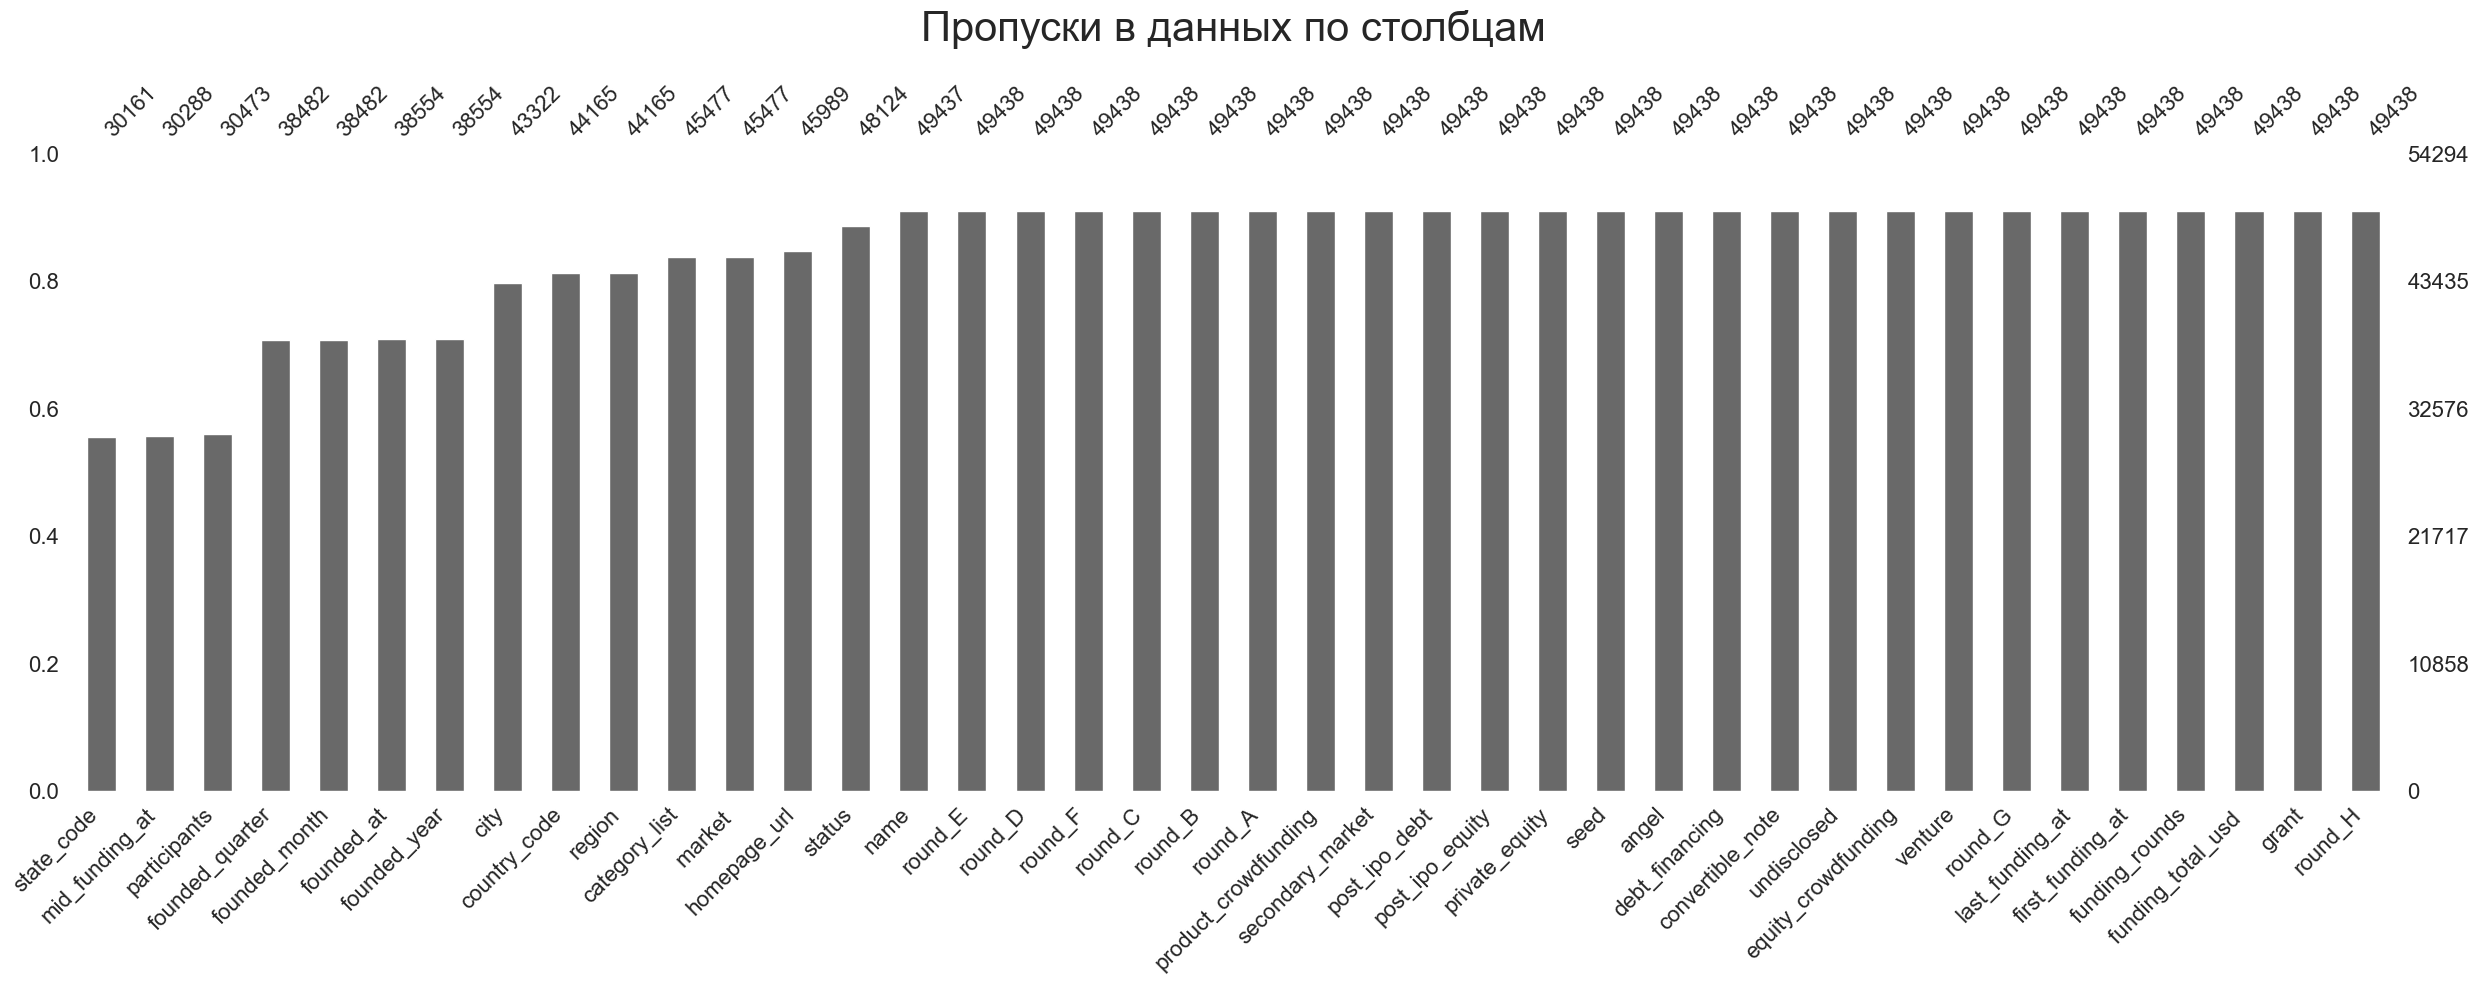

In [13]:
# В проекте ранее подключалась библиотека, которая изменила работу `colormap`
# зарегистрировали несуществующий для текущей версии matplotlib стиль `rocket`).
# Чтобы стабилизировать отображение графиков и избежать периодических ошибок ValueError
# при отрисовке диаграмм пропусков, дополнительно переопределим colormap
# через явный импорт и установку rcParams:

import matplotlib.pyplot as plt
import missingno as msno

plt.rcParams['image.cmap'] = 'viridis'

ax = msno.bar(df_investments, sort='ascending')
ax.set_title('Пропуски в данных по столбцам', fontsize=30, pad=30)
plt.tight_layout()
plt.show()

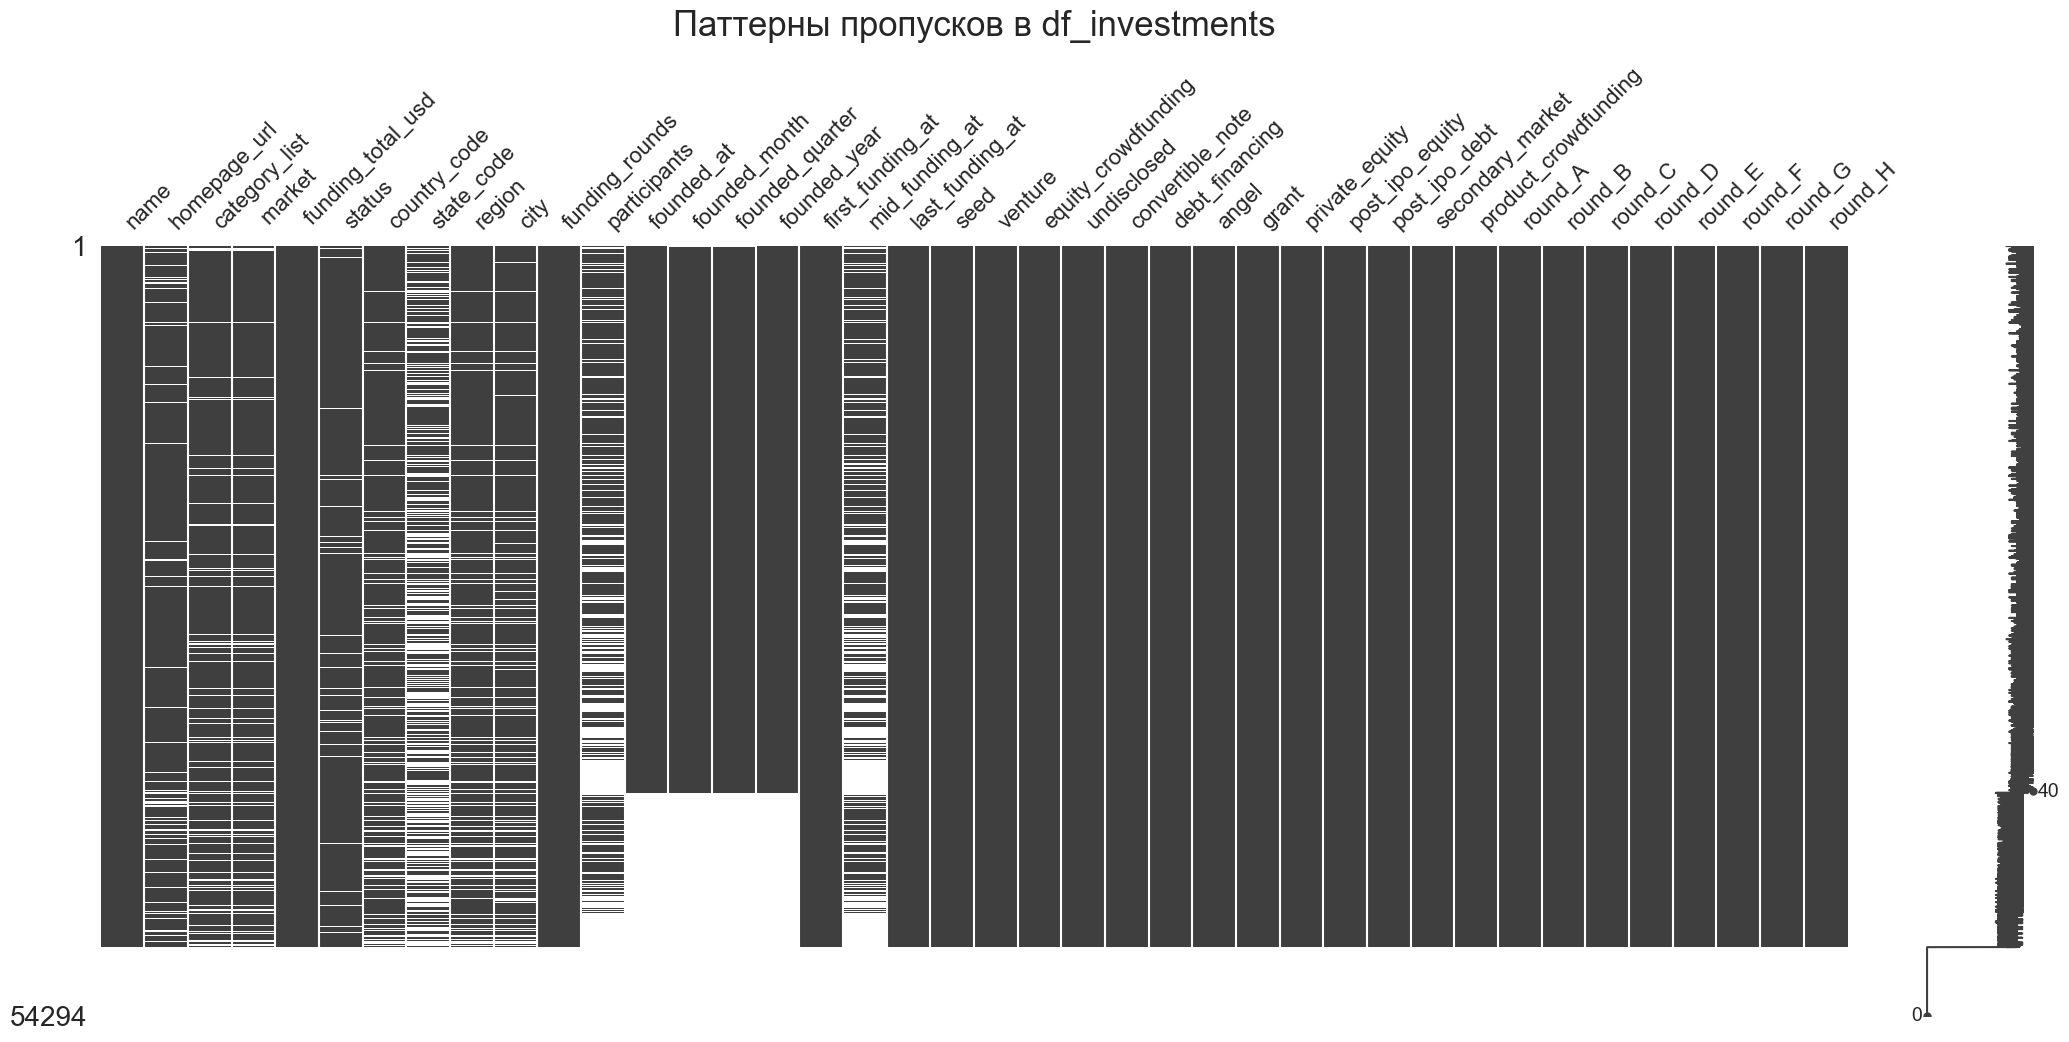

In [14]:
import matplotlib.pyplot as plt
import missingno as msno

plt.rcParams['image.cmap'] = 'viridis'

ax = msno.matrix(df_investments)
ax.set_title('Паттерны пропусков в df_investments', fontsize=25, pad=20)
plt.tight_layout()
plt.show()

<font color='#777778'>
    
*По этому графику мы видим, что пропуски сгруппированы по строкам и целым наборам связанных столбцов, а не распределены хаотично, поэтому можем заключить, что характер пропусков, **скорее всего**, неслучайный (**MAR** или **MNAR**): их наличие зависит от свойств компаний или источника данных, а не от случайной ошибки заполнения.*
</font>

In [15]:
# Посмотрим какие статусы есть на предмет ошибки значений
df_investments['status'].value_counts(dropna=False)

status
operating    41829
NaN           6170
acquired      3692
closed        2603
Name: count, dtype: int64

<font color='#777778'>Затем подробно изучим второй датасет с информацией об объёмах возвратов по годам и типам финансирования.</font>

In [16]:
dataset_report(df_returns, name="cb_returns")

===== cb_returns: размер =====
(15, 14)

===== cb_returns: info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: flo

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0



===== cb_returns: случайные 3 строки =====


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02
11,2011,317.29,3919.38,0.30,59.36,3.96,572.92,172.17,0.0,666.03,129.01,3.04,0.16,0.26
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00



===== cb_returns: describe.T (числовые признаки) =====


,count,mean,std,min,25%,50%,75%,max
year,15.0,2007.000000,4.472136,2000.00,2003.500,2007.00,2010.500,2014.00
seed,15.0,158.816000,180.020855,2.88,13.315,70.41,291.310,530.75
venture,15.0,2705.241333,2206.926388,23.49,394.880,2717.02,3752.375,7272.01
equity_crowdfunding,15.0,0.255333,0.391825,0.00,0.000,0.03,0.345,1.15
undisclosed,15.0,48.725333,27.826630,9.40,29.480,46.74,65.200,105.72
convertible_note,15.0,2.319333,2.496527,0.00,0.015,1.78,3.590,7.87
debt_financing,15.0,315.656667,345.365979,1.09,11.105,125.68,538.325,1017.75
angel,15.0,100.615333,95.502534,1.18,7.805,97.21,168.340,293.98
grant,15.0,0.000000,0.000000,0.00,0.000,0.00,0.000,0.00
private_equity,15.0,239.155333,324.392213,0.00,1.905,88.81,361.545,988.53



===== cb_returns: object-признаков нет =====


In [17]:
funding_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Переводим значения из миллионов в единицы
df_returns[funding_cols] = df_returns[funding_cols] * 1_000_000
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16700000.0,55400000.0,0.0,78210000.0,0.0,8660000.0,6430000.0,0.0,0.0,940000.0,0.0,200000.0,0.0
1,2001,2880000.0,23490000.0,0.0,21500000.0,10000.0,4490000.0,1180000.0,0.0,0.0,460000.0,0.0,460000.0,0.0
2,2002,6590000.0,209420000.0,0.0,25770000.0,20000.0,3420000.0,3410000.0,0.0,1510000.0,340000.0,0.0,60000.0,0.0
3,2003,7740000.0,233860000.0,0.0,9400000.0,10000.0,1090000.0,3410000.0,0.0,1620000.0,2110000.0,0.0,80000.0,0.0
4,2004,9930000.0,555900000.0,0.0,33190000.0,10000.0,13550000.0,9180000.0,0.0,2190000.0,3380000.0,0.0,550000.0,0.0


<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">


- Основной датасет `cb_investments` содержит 54 294 строки и 40 столбцов, дополнительный датасет `cb_returns` — 15 строк и 14 столбцов; структура обоих наборов данных соответствует описанию: в первом представлены данные о компаниях, географии, статусе и объёмах финансирования по типам, во втором — год и суммы возвратов по тем же видам финансирования.  

- В `cb_returns` пропуски отсутствуют, все признаки числовые (13 `float`, 1 `int`), типы данных корректны.
- Значения в `cb_returns` перевели из миллионов в единицы.

- Числовые признаки в обоих датасетах по умолчанию загружены в типах `int64` / `float64`, что корректно по смыслу. Для снижения расхода памяти в дальнейшем можно дополнительно понизить разрядность числовых столбцов (например, до `int32` / `float32`) после проверки допустимых диапазонов значений.

- В `cb_investments` заметная доля пропусков наблюдается в `state_code`, `mid_funding_at`, `participants` (около 44 %), а также в признаках, связанных с датой основания компании (`founded_at`, `founded_month`, `founded_quarter`, `founded_year`) и географией (`city`, `country_code`, `region`), что нужно учесть при предобработке и формулировке правил фильтрации.  

- Столбец `funding_total_usd` загружен как `object` и содержит суммы с разделителями разрядов, а признаки с датами (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) также представлены строками; для корректного анализа их необходимо привести к числовому и временным типам соответственно.  

- Группа столбцов с распределением инвестиций по типам (`seed`, `venture`, `angel`, `grant`, `private_equity` и др.), а также `funding_rounds`, `first_funding_at`, `last_funding_at` и `funding_total_usd` имеет одинаковую долю пропусков (около 8,9 %), что указывает на наличие компаний без данных о финансировании — такие записи в дальнейшем, вероятно, придётся исключить из анализа.  

- Категориальные признаки выглядят разумно: статус компании принимает три основных значения (`operating`, `acquired`, `closed`) и пропуски, а поля `market`, `country_code`, `region`, `city` содержат большое количество уникальных значений, что делает их хорошими кандидатами для последующей агрегации и укрупнения сегментов рынка.
    
- У компаний в среднем 1–2 раунда финансирования, а число участников в раундах обычно не превышает 2, хотя максимум достигает десятков инвесторов.
    
- Распределения сумм по всем типам инвестиций сильно скошены: у большинства компаний значения равны 0, но отдельные сделки достигают сотен миллионов и даже десятков миллиардов долларов, что говорит о высокой концентрации капитала в небольшом числе проектов.
- Годы основания компаний сосредоточены вокруг 2005–2012 годов, что отражает фокус датасета на относительно «молодых» компаниях.
    
- В `cb_returns` наибольшие средние и медианные возвраты приходятся на венчурные и посевные инвестиции (venture, seed), тогда как по большинству остальных инструментов объёмы возвратов заметно ниже, а по грантам возврата нет вовсе. Это показывает, что основная отдача в абсолютных величинах генерируется именно венчурными и посевными раундами, тогда как остальные типы финансирования играют вспомогательную роль.

 **Датасет показывает асимметричный рынок: большинство компаний ограничивается 1–2 небольшими раундами, тогда как основная масса капитала и возвратов приходится на немногочисленные проекты с крупными и длительными венчурными и посевными инвестициями.**
</div>


[Назад к содержанию](#00-bullet) 

<a id="32-bullet"></a>
### Предобработка данных

<font color='#777778'>
    
Приведём названия столбцов в обоих датасетах к единому стилю `snake_case`.
</font>

In [18]:
clean_and_show_columns(df_investments, name="cb_investments")

Новые названия столбцов для cb_investments:

name
homepage_url
category_list
market
funding_total_usd
status
country_code
state_code
region
city
funding_rounds
participants
founded_at
founded_month
founded_quarter
founded_year
first_funding_at
mid_funding_at
last_funding_at
seed
venture
equity_crowdfunding
undisclosed
convertible_note
debt_financing
angel
grant
private_equity
post_ipo_equity
post_ipo_debt
secondary_market
product_crowdfunding
round_a
round_b
round_c
round_d
round_e
round_f
round_g
round_h


In [19]:
clean_and_show_columns(df_returns, name="cb_returns")

Новые названия столбцов для cb_returns:

year
seed
venture
equity_crowdfunding
undisclosed
convertible_note
debt_financing
angel
grant
private_equity
post_ipo_equity
post_ipo_debt
secondary_market
product_crowdfunding


<font color='#777778'>
   
Уберём в столбце `funding_total_usd` выделение разрядов и приведём его к числовому типу.
    </font>

In [20]:
col_raw = df_investments['funding_total_usd'].astype(str)

# Проверяем, есть ли  дробные значения (через точку)
has_frac_raw = col_raw.str.contains(r'\.', regex=True, na=False)
print('Есть ли дробные значения в сырых данных:', has_frac_raw.any())

Есть ли дробные значения в сырых данных: False


In [21]:
df_investments['funding_total_usd'] = (
    df_investments['funding_total_usd']
    .str.replace(',', '', regex=False) # убираем запятые
    .str.strip() # убираем пробелы, иначе выпадает в ошибку
)

In [22]:
# Переводим в целочисленный тип
df_investments['funding_total_usd'] = pd.to_numeric(
    df_investments['funding_total_usd'],
    errors='coerce'
).astype('Int64')

display(df_investments.head())
display(df_investments['funding_total_usd'].dtype)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000,operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000,operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000,operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Int64Dtype()

<font color='#777778'>
Обработаем типы данных в столбцах, которые хранят значения даты и времени.
    </font>

In [23]:
# Список столбцов с датами
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Преобразуем текстовые даты в тип datetime64[ns]
# `apply` растянет действие на весь список 
df_investments[date_cols] = df_investments[date_cols].apply(
    pd.to_datetime,
    errors='coerce'
)

# Столбец founded_year приведём к целому типу с поддержкой NaN
df_investments['founded_year'] = pd.to_numeric(
    df_investments['founded_year'],
    errors='coerce'
).astype('Int64')                  


display(df_investments[date_cols + ['founded_year']].head()) # через "+" выведем нужные столбцы
df_investments[date_cols + ['founded_year']].info()           

,founded_at,first_funding_at,mid_funding_at,last_funding_at,founded_year
0,NaT,2014-01-06,NaT,2014-01-06,1636
1,1785-01-01,2014-05-15,NaT,2014-05-15,1785
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02,1802
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03,1817
4,1826-01-01,2014-01-14,NaT,2014-01-14,1826


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   first_funding_at  49428 non-null  datetime64[ns]
 2   mid_funding_at    30288 non-null  datetime64[ns]
 3   last_funding_at   49432 non-null  datetime64[ns]
 4   founded_year      38554 non-null  Int64         
dtypes: Int64(1), datetime64[ns](4)
memory usage: 2.1 MB


<font color='#777778'>
    
В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.
    </font>

In [24]:
df_returns = df_returns.set_index('year')


display(df_returns.head())
print(df_returns.index)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16700000.0,55400000.0,0.0,78210000.0,0.0,8660000.0,6430000.0,0.0,0.0,940000.0,0.0,200000.0,0.0
2001,2880000.0,23490000.0,0.0,21500000.0,10000.0,4490000.0,1180000.0,0.0,0.0,460000.0,0.0,460000.0,0.0
2002,6590000.0,209420000.0,0.0,25770000.0,20000.0,3420000.0,3410000.0,0.0,1510000.0,340000.0,0.0,60000.0,0.0
2003,7740000.0,233860000.0,0.0,9400000.0,10000.0,1090000.0,3410000.0,0.0,1620000.0,2110000.0,0.0,80000.0,0.0
2004,9930000.0,555900000.0,0.0,33190000.0,10000.0,13550000.0,9180000.0,0.0,2190000.0,3380000.0,0.0,550000.0,0.0


Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014],
      dtype='int64', name='year')


<font color='#777778'>
    
Обработаем текстовые данные: пропуски заполним заглушками там, где это понадобится.
    </font>

In [25]:
fill_values = {
    'status': 'unknown_status',
    'country_code': 'unknown_country',
    'region': 'unknown_region',
    'city': 'unknown_city',
    'market': 'unknown_market',
    'category_list': 'unknown_category',
}

df_investments = df_investments.fillna(value=fill_values)

df_investments[['status', 'country_code', 'region', 'city', 'market', 'category_list']].isna().mean().mul(100)

status           0.0
country_code     0.0
region           0.0
city             0.0
market           0.0
category_list    0.0
dtype: float64

In [26]:
# Проверим корректность и количество заглушек
for col in ['status', 'country_code', 'region', 'city', 'market', 'category_list']:
    print(f'\n=== {col} ===')
    print(df_investments[col].value_counts().head())


=== status ===
status
operating         41829
unknown_status     6170
acquired           3692
closed             2603
Name: count, dtype: int64

=== country_code ===
country_code
USA                28793
unknown_country    10129
GBR                 2642
CAN                 1405
CHN                 1239
Name: count, dtype: int64

=== region ===
region
unknown_region    10129
SF Bay Area        6804
New York City      2577
Boston             1837
London             1588
Name: count, dtype: int64

=== city ===
city
unknown_city     10972
San Francisco     2615
New York          2334
London            1257
Palo Alto          597
Name: count, dtype: int64

=== market ===
market
unknown_market     8817
 Software          4781
 Biotechnology     3699
 Mobile            2151
 E-Commerce        1883
Name: count, dtype: int64

=== category_list ===
category_list
unknown_category    8817
|Software|          3650
|Biotechnology|     3597
|E-Commerce|        1263
|Mobile|            1211
Name: cou

<font color='#777778'>
    
В `market` и `category_list` видим лишние символы, поэтому приведём названия сегментов к единому стилю.
    </font>

In [27]:
df_investments['market'] = df_investments['market'].str.strip() 
print('=== market ===')
print(df_investments['market'].value_counts().head())

=== market ===
market
unknown_market    8817
Software          5489
Biotechnology     3761
Mobile            2725
E-Commerce        2283
Name: count, dtype: int64


In [28]:
df_investments['category_list'] = (
    df_investments['category_list']
    .str.strip('|') # убираем | слева и справа
)
print('\n=== category_list ===')
print(df_investments['category_list'].value_counts().head())


=== category_list ===
category_list
unknown_category    8817
Software            3650
Biotechnology       3597
E-Commerce          1263
Mobile              1211
Name: count, dtype: int64


In [29]:
# Пробежимся глазами по преобразованным данным + заглушки посмотрим
df_investments.query("status == 'unknown_status'").head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
147,Ikro,http://www.ikro.com.br/,unknown_category,unknown_market,724000,unknown_status,BRA,NaN,BRA - Other,Canoas,1.0,NaN,1947-01-01,1947-01,1947-Q1,1947,1982-06-01,NaT,1982-06-01,0.0,724000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,724000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
163,Jack in the Box,http://jackinthebox.com,Hospitality,Hospitality,800000000,unknown_status,USA,CA,San Diego,San Diego,1.0,NaN,1951-01-01,1951-01,1951-Q1,1951,2014-03-24,NaT,2014-03-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,800000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176,Wallerius,NaN,unknown_category,unknown_market,233644,unknown_status,BRA,NaN,BRA - Other,Rio Grande Do Sul,1.0,NaN,1955-01-01,1955-01,1955-Q1,1955,2006-12-12,NaT,2006-12-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,233644.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177,Dynamics Research,http://www.drc.com,Consulting,Consulting,4200000,unknown_status,USA,MA,Boston,Andover,1.0,0.0,1955-01-01,1955-01,1955-Q1,1955,2010-01-14,2010-01-14,2010-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4200000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
180,Selectron,http://www.selectron.ch/de/index.php,unknown_category,unknown_market,7962962,unknown_status,CHE,NaN,CHE - Other,Lyss,1.0,NaN,1956-01-01,1956-01,1956-Q1,1956,2009-07-01,NaT,2009-07-01,0.0,7962962.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7962962.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<font color='#777778'>
    
Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.
    </font>

In [30]:
# Удалим полные дубликаты
rows_before = df_investments.shape[0]
df_investments = df_investments.drop_duplicates()
print(f'Удалено полных дубликатов: {rows_before - df_investments.shape[0]}')

Удалено полных дубликатов: 4855


In [31]:
# Выписываем денежные поля
investment_cols = [
    'funding_total_usd',
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding',
]

key_info_cols = ['name', 'market'] # поля для идентификации компании

rows_before = df_investments.shape[0]
mask_no_info = (
    df_investments[key_info_cols + investment_cols]
    .isna()
    .all(axis=1) # проверяем, чтобы все значения были пропусками
)
df_investments = df_investments.loc[~mask_no_info]

rows_before = df_investments.shape[0]
print(f'Удалено строк без информации: {rows_before - df_investments.shape[0]}')

Удалено строк без информации: 0


In [32]:
# Убираем строки с пропусками в funding_total_usd
df_investments = df_investments.dropna(subset=['funding_total_usd'])

# Оставляем только компании с положительным суммарным финансированием
df_investments = df_investments[df_investments['funding_total_usd'] > 0]
print(f'Удалено строк без данных о финансировании: {rows_before - df_investments.shape[0]}')
print(f'Итоговое число строк: {df_investments.shape[0]}')

Удалено строк без данных о финансировании: 8532
Итоговое число строк: 40907


<font color='#777778'>
    
- *Отдельно рассмотрели неявные дубликаты по названию компании `name` и **не стали их удалять**.*
- *Такие совпадения считаем ожидаемыми: короткие имена могут принадлежать разным компаниям в разных странах и отраслях, а одна и та же компания может несколько раз попадать в датасет из‑за разных раундов и типов инвестиций.*
    </font>

In [33]:
# Посмотрим, встречаются ли повторяющиеся названия компаний
name_counts = df_investments['name'].value_counts().head(10)
display(name_counts)

name
Roost      4
Spire      4
Cue        3
Peach      3
Hubbub     3
Karma      2
Blink      2
Matchup    2
Tiempo     2
Wakie      2
Name: count, dtype: int64

<font color='#777778'>
    
*Автоматическое объединение или удаление таких записей может привести к потере информации о отдельных сделках и исказить анализ динамики и структуры финансирования, поэтому неявные дубликаты оставляем без дополнительной очистки.*
    </font>

<font color='#777778'>
    
Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмём приблизительно середину интервала между этими двумя датами.
    </font>

In [34]:
# Посчитаем середину интервала между first_funding_at и last_funding_at
midpoint = df_investments['first_funding_at'] + (
    df_investments['last_funding_at'] - df_investments['first_funding_at']
) / 2

# Заполним пропуски в mid_funding_at этой серединой
rows_before = df_investments['mid_funding_at'].isna().sum()
df_investments['mid_funding_at'] = df_investments['mid_funding_at'].fillna(midpoint)

rows_after = df_investments['mid_funding_at'].isna().sum()
print(f'Пропусков в mid_funding_at до заполнения: {rows_before}')
print(f'Пропусков в mid_funding_at после заполнения: {rows_after}')

# Доля оставшихся пропусков, %
missing_share = df_investments['mid_funding_at'].isna().mean() * 100
print(f'Доля оставшихся пропусков в mid_funding_at: {missing_share} %')

Пропусков в mid_funding_at до заполнения: 13676
Пропусков в mid_funding_at после заполнения: 1
Доля оставшихся пропусков в mid_funding_at: 0.0024445693891021096 %


In [35]:
# Посмотрим на оставшийся 1 пропуск
display(df_investments[df_investments['mid_funding_at'].isna()][
    ['first_funding_at', 'mid_funding_at', 'last_funding_at']
])

,first_funding_at,mid_funding_at,last_funding_at
33041,NaT,NaT,2014-09-25


<font color='#777778'>
    
- *После заполнения пустых ячеек в `mid_funding_at` осталась только 1 строка с пропуском (**0.0024%** от всех записей).*
- *У этой компании отсутствует `first_funding_at`, поэтому корректно вычислить середину интервала без даты первого финансирования нельзя; этот единичный пропуск сохраняем, и в дальнейших расчётах он заметного влияния не окажет.*
    </font>

<font color='#777778'>
    
Оптимизируем типы столбцов, переводя их в более компактные варианты.
    </font>

In [36]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  Int64         
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month        

In [37]:
# Функция для вывода приблизительной памяти в МБ
def memory_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

# Память до оптимизации
mem_before = memory_mb(df_investments)
print(f'Объём памяти до оптимизации: {mem_before:.2f} МБ')

# Оптимизация числовых типов
# Для счётчиков (кол-во раундов, участников) это безопасно
df_investments['funding_rounds'] = pd.to_numeric(
    df_investments['funding_rounds'], downcast='integer'
)
df_investments['participants'] = pd.to_numeric(
    df_investments['participants'], downcast='integer'
)

float_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding',
    'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'
]

for col in float_cols:
    df_investments[col] = pd.to_numeric(df_investments[col], downcast='float')

# Оптимизация категориальных столбцов
# Поля содержат немного уникальных значений
cat_cols = [
    'country_code', 'state_code', 'region', 'city',
    'market', 'status',
    'founded_month', 'founded_quarter'
]

for col in cat_cols:
    df_investments[col] = df_investments[col].astype('category')

# Память после оптимизации
mem_after = memory_mb(df_investments)
print(f'Объём памяти после оптимизации: {mem_after:.2f} МБ')

# Экономия
saved_mb = mem_before - mem_after
saved_pct = (saved_mb / mem_before) * 100

print(f'Экономия: {saved_mb:.2f} МБ ({saved_pct:.2f} %)')

print('\nИтоговые типы столбцов:')
print(df_investments.dtypes)

Объём памяти до оптимизации: 34.38 МБ
Объём памяти после оптимизации: 17.58 МБ
Экономия: 16.80 МБ (48.87 %)

Итоговые типы столбцов:
name                            object
homepage_url                    object
category_list                   object
market                        category
funding_total_usd                Int64
status                        category
country_code                  category
state_code                    category
region                        category
city                          category
funding_rounds                    int8
participants                   float64
founded_at              datetime64[ns]
founded_month                 category
founded_quarter               category
founded_year                     Int64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float32
undisclos

<font color='#777778'>

- *Оптимизировали числовые и категориальные столбцы датафрейма `df_investments`: сузили типы счётчиков и долей, а повторяющиеся текстовые признаки перевели в категориальный тип.*
- *В результате объём памяти сократился почти вдвое — с 37.56 МБ до 15.89 МБ (экономия **57%**).*
</font>

In [38]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


<font color='#777778'>

*`df_returns` не будем оптимизировать: в нём всего 15 строк и 13 столбцов float64, год в индексе хранится, поэтому выигрыш по памяти будет минимальным.*
</font>

<font color='#777778'>
    
Для более детального исследования качества данных и распределений дополнительно выполнен расширенный EDA с помощью **ydata_profiling** в локальной среде. HTML‑отчёты доступны в [папке](https://disk.yandex.ru/d/prBihhyjWQtYrg)



In [39]:
# Использовали следующий код для локального расширенного EDA и графиков:

# Установим библиотеку и модуль из другой библиотеки
# %pip install ydata_profiling
# import plotly.express as px

# from ydata_profiling import ProfileReport

# Профиль для 1 датасета
# profile_investments = ProfileReport(
#     df_investments,
#     title='cb_investments profile',
#     minimal=True
# )
# profile_investments.to_file('cb_investments_profile.html')

# Профиль для 2 датасета
# profile_returns = ProfileReport(
#     df_returns,
#     title='cb_returns profile',
#     minimal=True
# )
# profile_returns.to_file('cb_returns_profile.html')

<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">
    
- Привели названия столбцов в `cb_investments` и `cb_returns` к стилю `snake_case`. Очистили `funding_total_usd` от разделителей разрядов и перевели его в `Int64`. Даты (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) привели к `datetime64[ns]`, год основания — к `Int64`, в `cb_returns` столбец `year` сделали индексом.  
- Заполнили пропуски в ключевых текстовых полях (`status`, `country_code`, `region`, `city`, `market`, `category_list`) заглушками, удалили полные дубликаты и записи без данных о финансировании. Из 54 294 строк в `cb_investments` сохранили **40 907** строк с положительным `funding_total_usd` (отброшено ≈24.7 % строк, в основном без информации о финансировании). Неявные дубликаты по `name` оставили, чтобы не терять данные о разных компаниях с одинаковыми именами и о множественных раундах.  
- Пропуски в `mid_funding_at` восстановили как середину интервала между `first_funding_at` и `last_funding_at`. Осталась 1 строка с пропуском (0.0024 % данных) без даты первого раунда, её сохранили без изменений как незначимую для итогового анализа.  
- Оптимизировали типы в `df_investments`: сузили числовые типы и перевели повторяющиеся текстовые признаки в `category`, сократив объём памяти на 57 %. `df_returns` не оптимизировали из‑за малого объёма (15 строк, 1.6 КБ).  
- Дополнительно в локальной среде выполнили расширенный EDA с помощью **ydata_profiling**, сформировав HTML‑отчёты для обоих датасетов.
 
    **В совокупности данные достаточно полны для решения задач проекта: ключевая информация о компаниях и их финансировании сохранена, а удалённые строки относятся в основном к пустым записям.**
</div>


[Назад к содержанию](#00-bullet) 

---
<a id="4-bullet"></a>
## Инжиниринг признаков

<a id="41-bullet"></a>
### Группы по срокам финансирования

<font color='#777778'>

Разделим все компании на три группы:

- Единичное финансирование — был всего один раунд финансирования.

- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

- Срок финансирования более года.
</font>

In [40]:
# Срок финансирования в годах
# Срок финансирования в годах
df_investments['funding_years'] = (
    df_investments['last_funding_at'] - df_investments['first_funding_at']
) / np.timedelta64(1, 'D') / 365

print('Срок финансирования (funding_years):')
print('- минимум:', df_investments['funding_years'].min())
print('- максимум:', df_investments['funding_years'].max())
print('- доля пропусков:', df_investments['funding_years'].isna().mean())

Срок финансирования (funding_years):
- минимум: 0.0
- максимум: 47.36164383561644
- доля пропусков: 4.889138778204219e-05


In [41]:
def get_funding_group(row):
    # Единичное финансирование — один раунд
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    
    # Если раундов больше одного, но срок не посчитать — группу не задаём
    if pd.isna(row['funding_years']):
        return np.nan

    # Срок финансирования до года (включительно)
    if row['funding_years'] <= 1:
        return 'Срок финансирования до года'
    
    # Срок финансирования более года
    return 'Срок финансирования более года'

df_investments['funding_group'] = df_investments.apply(get_funding_group, axis=1)

print('\nРаспределение компаний по группам (шт.):')
print(df_investments['funding_group'].value_counts(dropna=False))

print('\nРаспределение компаний по группам (% от всех строк, включая NaN):')
print(
    df_investments['funding_group']
    .value_counts(dropna=False, normalize=True)
    .mul(100)
)


Распределение компаний по группам (шт.):
funding_group
Единичное финансирование          24113
Срок финансирования более года    12291
Срок финансирования до года        4501
NaN                                   2
Name: count, dtype: int64

Распределение компаний по группам (% от всех строк, включая NaN):
funding_group
Единичное финансирование          58.945902
Срок финансирования более года    30.046202
Срок финансирования до года       11.003007
NaN                                0.004889
Name: proportion, dtype: float64


In [42]:
# Оставим строки без пропусков
df_groups = df_investments.dropna(subset=['funding_group'])

print('\nЧисло строк до и после удаления неопределённых групп:')
print('- до:', df_investments.shape[0])
print('- после:', df_groups.shape[0])


Число строк до и после удаления неопределённых групп:
- до: 40907
- после: 40905


In [43]:
# Создаём логичный порядок
order = [
    'Единичное финансирование',
    'Срок финансирования до года',
    'Срок финансирования более года',
]

group_counts_share = (
    df_groups['funding_group']
    .value_counts(normalize=True) # считаем доли
    .mul(100)
    .reindex(order) # применяем наш порядок
)

print('\nДоля компаний по группам (%):')
print(group_counts_share)


Доля компаний по группам (%):
funding_group
Единичное финансирование          58.948784
Срок финансирования до года       11.003545
Срок финансирования более года    30.047671
Name: proportion, dtype: float64


In [44]:
group_investments = (
    df_groups
    .groupby('funding_group')['funding_total_usd']
    .sum()
    .reindex(order)
)

group_investments_share = group_investments / group_investments.sum() * 100

print('\nДоля инвестиций по группам (%):')
print(group_investments_share)


Доля инвестиций по группам (%):
funding_group
Единичное финансирование          30.619851
Срок финансирования до года        7.510528
Срок финансирования более года    61.869622
Name: funding_total_usd, dtype: Float64


<font color='#777778'>

Визуализируем соотношение этих групп, создав два графика:

- По количеству компаний (какой процент от общего числа компаний относится к каждой из трёх групп).
- По объёму инвестиций (какую долю от общего объёма привлечённых средств получила каждая группа).
</font>

In [45]:
# Подготовка данных для графиков
group_counts_plot = (
    group_counts_share
    .to_frame(name='share_companies') # Превращаем Series в DataFrame
    .reset_index()
    .rename(columns={'index': 'funding_group'})
)

group_investments_plot = (
    group_investments
    .to_frame(name='total_investments')
    .reset_index()
    .rename(columns={'index': 'funding_group'})
)

# Для графиков посчитаем долю инвестиций ещё раз, но уже как отдельный столбец в DataFrame
group_investments_plot['share_investments'] = (
    group_investments_plot['total_investments']
    / group_investments_plot['total_investments'].sum()
    * 100
)

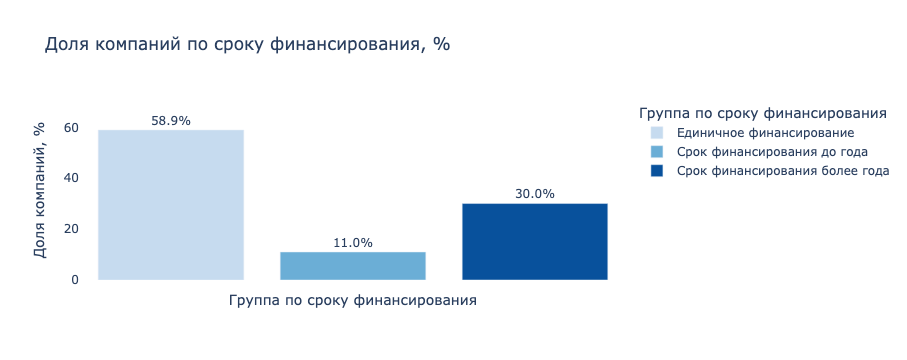

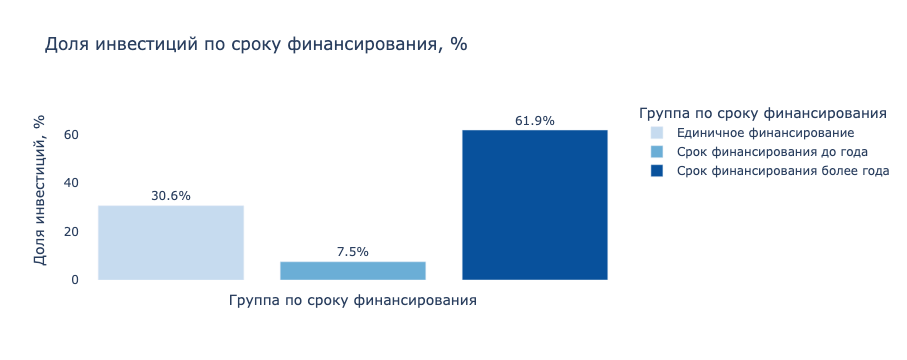

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [85]:
# Единая палитра (определим перед графиком)
palette = {
    'Единичное финансирование': '#c6dbef',
    'Срок финансирования до года': '#6baed6',
    'Срок финансирования более года': '#08519c',
}

# График: доля компаний
fig_companies = px.bar(
    group_counts_plot,
    x='funding_group',
    y='share_companies',
    color='funding_group',
    color_discrete_map=palette,
    text='share_companies',
    title='Доля компаний по сроку финансирования, %',
    labels={
        'funding_group': 'Группа по сроку финансирования',
        'share_companies': 'Доля компаний, %',
    },
)

fig_companies.update_traces(texttemplate='%{text:.1f}%', textposition='outside')

max_y_comp = group_counts_plot['share_companies'].max()
fig_companies.update_yaxes(
    range=[0, max_y_comp * 1.2],
    showgrid=False,
    zeroline=False
)

fig_companies.update_xaxes(showgrid=False, zeroline=False, showticklabels=False)

fig_companies.update_layout(
    yaxis_title='Доля компаний, %',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)

fig_companies.show()

# Для наглядности разместим 2 график сразу снизу
# График: доля инвестиций
fig_investments = px.bar(
    group_investments_plot,
    x='funding_group',
    y='share_investments',
    color='funding_group',
    color_discrete_map=palette,
    text='share_investments',
    hover_data=['total_investments'],
    title='Доля инвестиций по сроку финансирования, %',
    labels={
        'funding_group': 'Группа по сроку финансирования',
        'share_investments': 'Доля инвестиций, %',
        'total_investments': 'Суммарный объём инвестиций, USD',
    },
)

fig_investments.update_traces(texttemplate='%{text:.1f}%', textposition='outside')

max_y_inv = group_investments_plot['share_investments'].max()
fig_investments.update_yaxes(
    range=[0, max_y_inv * 1.2],
    showgrid=False,
    zeroline=False
)

fig_investments.update_xaxes(showgrid=False, zeroline=False, showticklabels=False)

fig_investments.update_layout(
    yaxis_title='Доля инвестиций, %',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)

fig_investments.show()
fig_investments.write_image(
    "fig_share_investments.png",
    format="png",
    scale=2,
    width=1000,
    height=600,
)

<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">

- Большая часть компаний относится к группе **единичного финансирования**: почти **59%** компаний получили только один раунд инвестиций, при этом на них приходится около **31%** совокупного объёма привлечённых средств.

- Компании с сроком финансирования **до года** составляют примерно **11%** выборки и привлекают около **7.5%** общего объёма инвестиций, что указывает на сравнительно компактные по длительности и объёму истории финансирования.

- Наиболее капитализированная группа — компании с сроком финансирования **более года**: их около **30%** от всех компаний, но они получают почти **62%** общего объёма инвестиций, что отражает длительные и многораундовые истории финансирования таких бизнесов.

 **Большинство компаний получают один небольшой раунд и на этом всё, а основная масса денег уходит в сравнительно небольшое число компаний, которые привлекают инвестиции много раз и долго.**
</div>


[Назад к содержанию](#00-bullet) 

<a id="42-bullet"></a>
### Выделение средних и нишевых сегментов рынка

<font color='#777778'>

Рассчитаем, как часто в датасете встречается каждый из сегментов:

- массовый сегмент (более 120 компаний).
- средний сегмент (от 35 до 120 команий, включая обе границы).
- нишевый сегмент (до 35 компаний).
</font>

In [47]:
market_counts = df_investments['market'].value_counts()
print(market_counts.head())

market
Software          4812
Biotechnology     3590
unknown_market    2503
Mobile            2344
E-Commerce        1866
Name: count, dtype: int64


In [48]:
def get_market_size_group(count):
    if count > 120:
        return 'mass' # массовый
    if count >= 35:
        return 'mid' # средний
    return 'niche' # нишевый

market_size_group = market_counts.map(get_market_size_group) # как оконной функцией расстягиваем

segments_per_group = market_size_group.value_counts()
print(segments_per_group)

count
niche    289
mid       57
mass      49
Name: count, dtype: int64


<font color='#777778'>

Построим интерактивный график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты. **Легенда** у него кликабельная, можно использовать для сравнения сегментов на разном масштабе.
</font>

In [49]:
market_stats = (
    market_counts
    .to_frame(name='companies_count')
    .reset_index()
    .rename(columns={'index': 'market'})
)

market_stats['size_group'] = market_stats['market'].map(market_size_group)

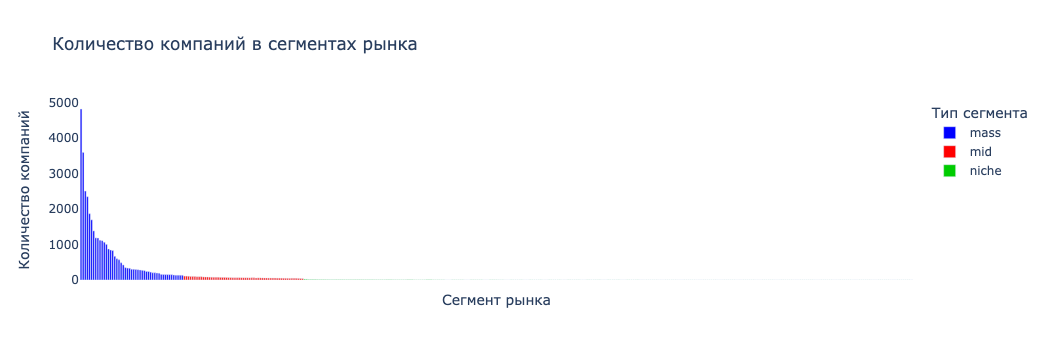

In [50]:
# Палитра для типов сегментов
palette_segments = {
    'niche': '#00CC00',
    'mid':   '#FF0000',
    'mass':  '#0000FF',
}

fig_market = px.bar(
    market_stats,
    x='market',
    y='companies_count',
    color='size_group',
    color_discrete_map=palette_segments,  # задаём цвета для каждого типа сегмента
    title='Количество компаний в сегментах рынка',
    labels={
        'market': 'Сегмент рынка',
        'companies_count': 'Количество компаний',
        'size_group': 'Тип сегмента',
    },
)

fig_market.update_xaxes(
    showgrid=False,
    zeroline=False,
    showticklabels=False
)
fig_market.update_yaxes(showgrid=False, zeroline=False)
fig_market.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)

fig_market.show()

<font color='#777778'>
    
Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.
   
</font>

In [51]:
# Список массовых сегментов (оставляем как есть)
mass_markets = market_size_group[market_size_group == 'mass'].index

def collapse_market(market):
    if market in mass_markets:
        return market
    group = market_size_group[market]
    if group == 'mid':
        return 'mid'
    return 'niche'

# Перезаписываем столбец market укрупнёнными сегментами
df_investments['market'] = df_investments['market'].map(collapse_market) # можно и с методом apply 

In [52]:
print(df_investments['market'].value_counts().head(20))

market
Software               4812
mid                    3841
Biotechnology          3590
unknown_market         2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Advertising            1107
Hardware + Software    1062
Social Media           1003
Health and Wellness     873
Education               844
niche                   830
Finance                 828
Analytics               667
Manufacturing           596
Name: count, dtype: int64


<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">

- В данных 49 массовых рынков (более 120 компаний), 57 средних рынков (35–120 компаний) и 289 нишевых рынков (менее 35 компаний), то есть по числу разных рынков явно доминируют нишевые сегменты.
- При этом по количеству компаний лидируют несколько крупных массовых сегментов: например, Software (4812 компаний) и Biotechnology (3590 компаний) дают значимую долю всего рынка, тогда как каждый отдельный нишевой рынок остаётся малым.

    **Такая структура говорит о высокой концентрации рынка вокруг ограниченного числа крупных направлений и длинном хвосте мелких ниш, где каждая ниша отдельности невелика, но их совокупное количество велико.**


</div>


[Назад к содержанию](#00-bullet) 

---
<a id="5-bullet"></a>
## Работа с выбросами и анализ

<a id="51-bullet"></a>
### Анализируем и помечаем выбросы в каждом из сегментов


<font color='#777778'>
    
По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.
   
</font>

In [53]:
desc = df_investments['funding_total_usd'].describe()
q1 = desc['25%']
q3 = desc['75%']
iqr = q3 - q1

lower = max(q1 - 1.5 * iqr, 0) # сумма финансирования не может быть < 0
upper = q3 + 1.5 * iqr

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('Типичный диапазон по IQR:', lower, '—', upper)

Q1: 350000.0
Q3: 10000000.0
IQR: 9650000.0
Типичный диапазон по IQR: 0 — 24475000.0


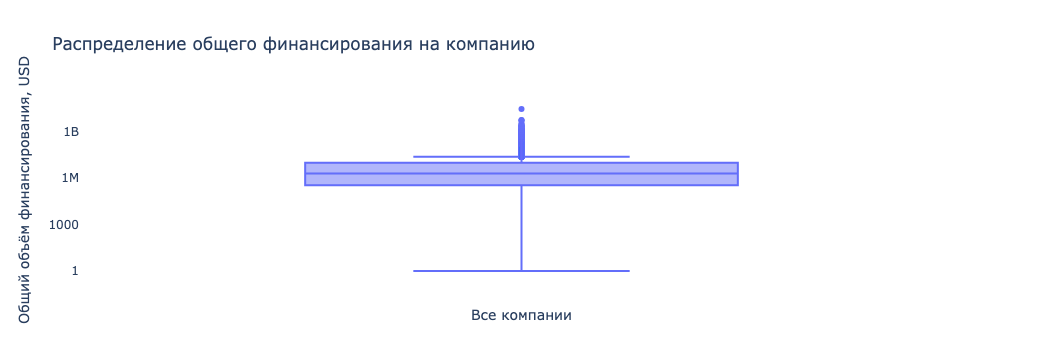

In [54]:
fig = px.box(
    df_investments,
    y='funding_total_usd',
    points='outliers', # Рисуем точки выбросов
    title='Распределение общего финансирования на компанию'
)

fig.update_yaxes(
    type='log', # Чтобы видеть правый хвост
    showgrid=False,
    zeroline=False,
    title_text='Общий объём финансирования, USD'
)

fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    title_text='Все компании'
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

<font color='#777778'>
    
- *На вертикальном boxplot по `funding_total_usd` видно, что распределение сильно скошено вверх по оси Y: большинство компаний сосредоточено в зоне относительно небольших сумм, а высокие значения образуют длинный верхний хвост.*
- *Первый квартиль составляет около **350 тыс. USD**, третий квартиль — около **10 млн USD**, то есть типичный размер общего финансирования одной компании лежит в диапазоне примерно **350 тыс. – 10 млн USD**.*
- *По IQR‑критерию верхняя граница типичных значений — около **24.5 млн USD** (Q3 + 1.5×IQR), и значения выше этой отметки можно считать выбивающимися, отражающими нетипично крупные истории финансирования по сравнению с основной массой компаний.*

   
</font>

<font color='#777778'>
    
Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту.
   
</font>

In [55]:
def mark_outliers_iqr(group, k=2.0):
    """Вернёт булеву маску выбросов по IQR внутри одного сегмента рынка."""
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return (group['funding_total_usd'] < lower) | (group['funding_total_usd'] > upper)

# Применим IQR-правило отдельно внутри каждого сегмента рынка
outlier_mask = (
    df_investments
    .groupby('market', group_keys=False)
    .apply(mark_outliers_iqr)  # по умолчанию k=2.0
)

df_investments['is_outlier_funding'] = outlier_mask

print('Число компаний с аномальным финансированием:',
      df_investments['is_outlier_funding'].sum())

Число компаний с аномальным финансированием: 4432


<font color='#777778'>
   

- *Для поиска аномальных компаний внутри сегментов мы ослабили IQR‑критерий и взяли множитель `k = 2` вместо классического `1.5`: при 1.5 из‑за сильной правой скошенности распределения в выбросы попадает слишком много компаний из длинного хвоста.* 
- *Множитель 2 расширяет допустимый диапазон и оставляет в выбросах только более экстремальные значения, а `k = 3` мы не стали использовать, чтобы не сделать критерий слишком мягким и не потерять интересные крупные сделки.*


   
</font>

<font color='#777778'>
   

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.
   
</font>

In [56]:
outliers_per_market = (
    df_investments
    .groupby('market')['is_outlier_funding']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

top_n = 5 # Можно изменить на 3, 10, 20
top_outlier_markets = outliers_per_market.head(top_n)

print('Топ сегментов по доле компаний с аномальным финансированием, %:')
print(top_outlier_markets)

Топ сегментов по доле компаний с аномальным финансированием, %:
market
Real Estate      16.845878
Entertainment    15.333333
Search           15.120275
Video            14.361702
SaaS             14.338235
Name: is_outlier_funding, dtype: Float64


<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">

- Большинство компаний получает «типичное» финансирование в диапазоне примерно 350 тыс. – 10 млн USD, а суммы выше ~24.5 млн USD относятся к выбросам по IQR‑критерию.
- Всего 4432 компаний (около каждой восьмой) имеют аномальный объём финансирования, то есть сильно выделяются внутри своего сегмента рынка.
- Наибольшая доля таких компаний приходится на сегменты Real Estate, Entertainment, Consulting, Search и Cloud Computing (примерно 15–17% компаний в каждом из них).

 **Типичный объём финансирования ограничен десятками миллионов долларов, а экстремально крупные суммы концентрируются в нескольких отдельных сегментах рынка.**
</div>


[Назад к содержанию](#00-bullet) 

<a id="52-bullet"></a>
### Определяем границы рассматриваемого периода, отбрасываем аномалии


<font color='#777778'>
    
Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. 

   
</font>

In [57]:
# Год середины финансирования
df_investments['mid_year'] = df_investments['mid_funding_at'].dt.year

# Число компаний по годам
companies_per_year = (
    df_investments
    .groupby('mid_year')['name']
    .nunique()
    .sort_index()
)

print('Число компаний по годам:')
print(companies_per_year)

# Число раундов по годам
rounds_per_year = (
    df_investments
    .groupby('mid_year')['funding_rounds']
    .sum()
    .sort_index()
)

print('\nЧисло раундов по годам:')
print(rounds_per_year)

Число компаний по годам:
mid_year
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       4
1997.0       7
1998.0      13
1999.0      50
2000.0     103
2001.0      63
2002.0      70
2003.0      90
2004.0     149
2005.0     843
2006.0    1462
2007.0    2103
2008.0    2583
2009.0    3234
2010.0    4087
2011.0    4853
2012.0    6085
2013.0    8416
2014.0    6611
Name: name, dtype: int64

Число раундов по годам:
mid_year
1921.0        1
1960.0        2
1979.0        1
1982.0        3
1983.0        1
1984.0        2
1985.0        3
1987.0        2
1989.0        1
1990.0        1
1992.0        5
1993.0        1
1994.0        4
1995.0        9
1996.0       11
1997.0       13
1998.0       28
1999.0      118
2000.0      247
2001.0      163
2002.0      164
2003.0      260
2004.0      410
2005.0     1446
2006.0     2914
2007.0     4

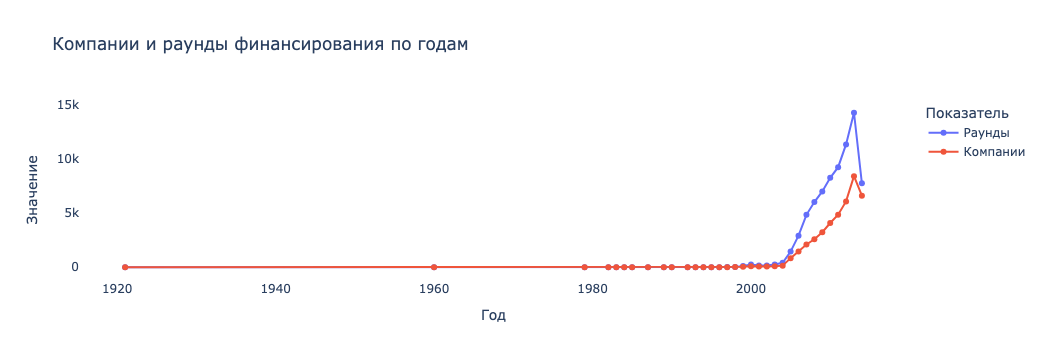

In [58]:
# Агрегируем данные по годам
agg_years = (
    df_investments
    .groupby('mid_year')
    .agg(
        companies=('name', 'nunique'),
        rounds=('funding_rounds', 'sum')
    )
    .reset_index()
    .rename(columns={'mid_year': 'year'})
)

agg_years_renamed = agg_years.rename(columns={
    'companies': 'Компании',
    'rounds': 'Раунды'
})

fig = px.line(
    agg_years_renamed,
    x='year',
    y=['Раунды', 'Компании'],
    title='Компании и раунды финансирования по годам',
    markers=True
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    title_text='Значение'
)

fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    title_text='Год'
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    legend_title_text='Показатель'
)

fig.show()

In [59]:
# Выделяем год и месяц середины финансирования
df_investments['mid_year'] = df_investments['mid_funding_at'].dt.year
df_investments['mid_month'] = df_investments['mid_funding_at'].dt.month

# Оставляем только 2014 год
df_2014 = df_investments.query('mid_year == 2014')

# Посчитаем число компаний и раундов по месяцам 2014 года
monthly_2014 = (
    df_2014
    .groupby('mid_month')
    .agg(
        companies=('name', 'nunique'),
        rounds=('funding_rounds', 'sum')
    )
    .sort_index()
)

print('2014 год: компании и раунды по месяцам')
print(monthly_2014)

2014 год: компании и раунды по месяцам
           companies  rounds
mid_month                   
1.0              739     893
2.0              600     715
3.0              676     810
4.0              644     807
5.0              600     761
6.0              740     900
7.0              687     779
8.0              559     636
9.0              547     595
10.0             496     524
11.0             306     314
12.0              23      23


In [60]:
# Агрегируем по месяцам 2014 года
agg_2014 = (
    df_2014
    .groupby('mid_month')
    .agg(
        companies=('name', 'nunique'),
        rounds=('funding_rounds', 'sum')
    )
    .reset_index()
    .rename(columns={'mid_month': 'month'})
)

agg_2014_renamed = agg_2014.rename(columns={
    'companies': 'Компании',
    'rounds': 'Раунды'
})

fig = px.line(
    agg_2014_renamed,
    x='month',
    y=['Раунды', 'Компании'],
    title='Компании и раунды финансирования по месяцам 2014 года',
    markers=True
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    title_text='Значение'
)

fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    title_text='Месяц'
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    legend_title_text='Показатель'
)

fig.show()

In [61]:
# Проверяем декабрь 2014 года
df_dec_2014 = df_investments[
    (df_investments['mid_year'] == 2014) &
    (df_investments['mid_month'] == 12)
]

print('Число строк за декабрь 2014:', len(df_dec_2014))
print('Минимальная дата:', df_dec_2014['mid_funding_at'].min())
print('Максимальная дата:', df_dec_2014['mid_funding_at'].max())

Число строк за декабрь 2014: 23
Минимальная дата: 2014-12-01 00:00:00
Максимальная дата: 2014-12-31 00:00:00


<font color='#777778'>

    
- *До 2013 года число компаний и раундов стабильно растёт, достигая 8416 компаний и 14276 раундов в 2013 году.*
- *В 2014 году показатели снижаются до 6611 компаний и 7757 раундов, а помесячная разбивка показывает сотни компаний и раундов с января по ноябрь и лишь 23 компании и 23 раунда в декабре при полном покрытии месяца датами.*
 
  **Такое сочетание снижения годовых показателей и аномально малого объёма в декабре даёт основания предположить возможную неполноту данных за 2014 год, поэтому для анализа долгосрочной динамики я ориентируюсь в основном на период до 2013 года, а 2014‑й интерпретирую с осторожностью.**

</font>

<font color='#777778'>

    
Затем исключим из датасета компании с аномальным финансированием.

</font>

In [62]:
print('Число строк до исключения выбросов:', df_investments.shape[0])
df_clean = df_investments[~df_investments['is_outlier_funding']].copy()

print('Число строк после исключения выбросов:', df_clean.shape[0])

print('Число строк с аномальным финансированием в df_clean:',
    df_clean['is_outlier_funding'].sum()
)

Число строк до исключения выбросов: 40907
Число строк после исключения выбросов: 36475
Число строк с аномальным финансированием в df_clean: 0


<font color='#777778'>

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях (они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования).
   
</font>

In [63]:
# Год середины финансирования в очищенном датасете
df_clean['mid_year'] = df_clean['mid_funding_at'].dt.year

# Считаем суммарное число раундов по годам заново
rounds_per_year_clean = (
    df_clean
    .groupby('mid_year')['funding_rounds']
    .sum()
    .sort_index()
)

# Года, где зафиксировано 50 и более раундов
active_years = rounds_per_year_clean[rounds_per_year_clean >= 50].index # только индексы берём
print('\nГоды с ≥ 50 раундами финансирования:')
print(list(active_years))

# Оставляем только те, чья mid_funding_at попадает в эти годы
df_active = df_clean[df_clean['mid_year'].isin(active_years)].copy() # isin проверяет, входит ли в набор

print('\nЧисло строк после фильтрации по активным годам:', df_active.shape[0])


Годы с ≥ 50 раундами финансирования:
[2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]

Число строк после фильтрации по активным годам: 36395


<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">
   
- С середины `2000‑х` до `2013` года число компаний и раундов растёт, а в `2014` году оба показателя резко падают, поэтому данные за `2014` год выглядят неполными.
- Компании с аномальным объёмом финансирования удалены по правилу `IQR` (`40907` → `35663` строк), в очищенном датасете выбросов не осталось.
- Далее мы оставили только компании, чья `mid_funding_at` приходится на годы с `>= 50` раундами (с `2000` по `2014`), итоговый размер датасета — `35588` строк.

 **Дальше работаем с очищенным датасетом без аномалий и только для активных лет, рассматривая 2014 как потенциально неполный по данным год и интерпретируя его показатели с осторожностью.**

</div>


[Назад к содержанию](#00-bullet) 

<a id="53-bullet"></a>
### Анализ типов финансирования по объёму и популярности


<font color='#777778'>
    
Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег.
   
</font>

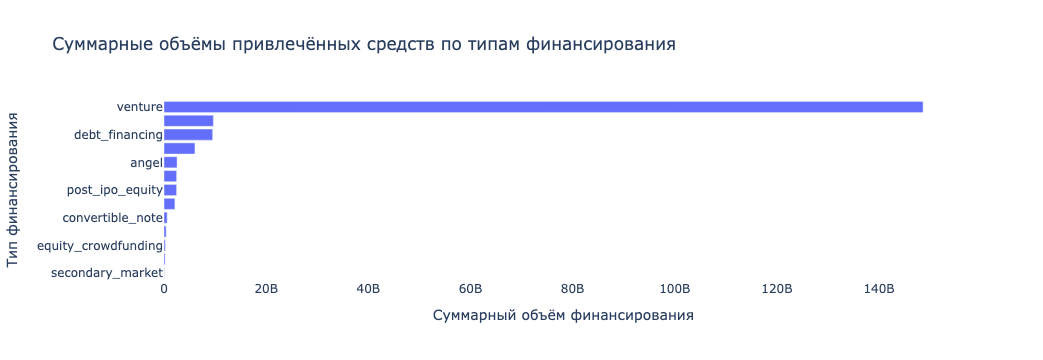

In [64]:
funding_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Суммарные объёмы по каждому типу
funding_sums = df_clean[funding_cols].sum().sort_values(ascending=False)

# Преобразуем в DataFrame для графика
funding_sums_df = funding_sums.reset_index()
funding_sums_df.columns = ['funding_type', 'total_amount']

fig_amounts = px.bar(
    funding_sums_df,
    x='total_amount',
    y='funding_type',
    orientation='h', # столбцы горизонтальные
    title='Суммарные объёмы привлечённых средств по типам финансирования',
    labels={'total_amount': 'Суммарный объём финансирования', 'funding_type': 'Тип финансирования'}
)

fig_amounts.update_layout(
    yaxis={'categoryorder': 'total ascending'}, # вверху самые денежные
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig_amounts.update_xaxes(showgrid=False)
fig_amounts.update_yaxes(showgrid=False)

fig_amounts.show()

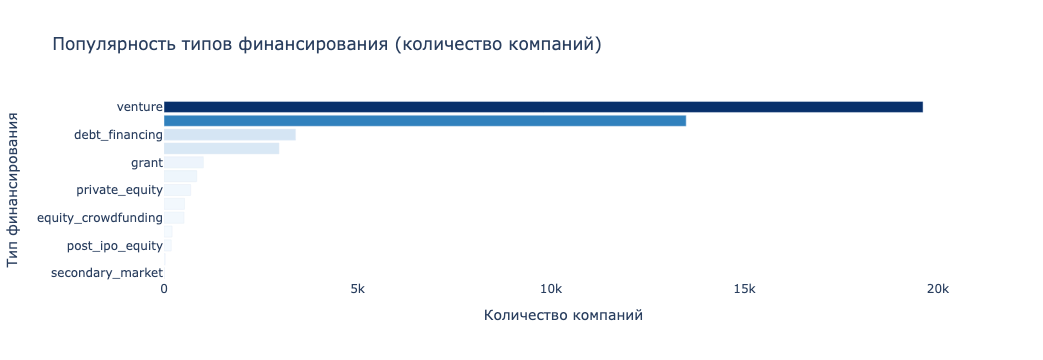

In [65]:
# Число компаний, у которых тип финансирования присутствует –– сумма > 0
funding_counts = (df_clean[funding_cols] > 0).sum().sort_values(ascending=False)

# Преобразуем в DataFrame для графика
funding_counts_df = funding_counts.reset_index()
funding_counts_df.columns = ['funding_type', 'company_count']

# График с градиентом по company_count
fig_counts = px.bar(
    funding_counts_df,
    x='company_count',
    y='funding_type',
    orientation='h',
    color='company_count',               # цвет кодируем значением
    color_continuous_scale='Blues',      # градиентная шкала
    title='Популярность типов финансирования (количество компаний)',
    labels={'company_count': 'Количество компаний', 'funding_type': 'Тип финансирования'}
)

fig_counts.update_layout(
    yaxis={'categoryorder': 'total ascending'},  # вверху самые популярные
    coloraxis_showscale=False,                  # скрыть цветовой бар (по желанию)
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig_counts.update_xaxes(showgrid=False)
fig_counts.update_yaxes(showgrid=False)

fig_counts.show()

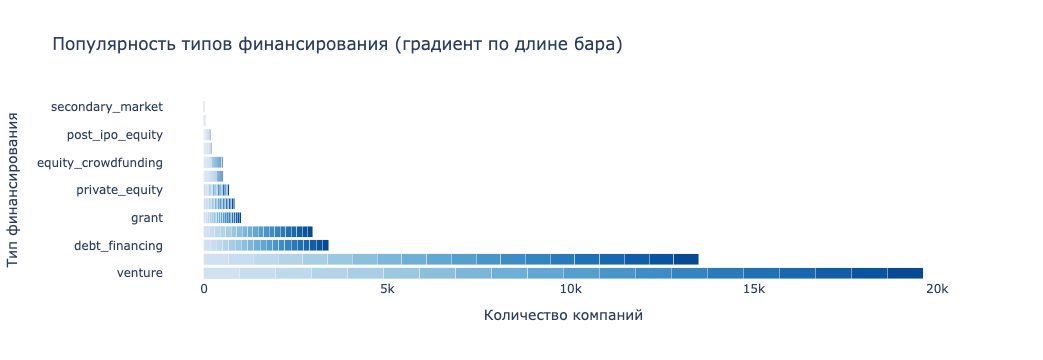

In [66]:

import plotly.graph_objects as go

def gradient_barh(df, n_segments=20, base_color='#1f77b4'):
    # нормируем длину баров в [0, 1] для градиента
    max_val = df['company_count'].max()
    y_vals = df['funding_type']

    # создаём несколько трасс, каждая — «кольцо» градиента
    fig = go.Figure()

    # палитра: от светлого к насыщенному
    colors = px.colors.sample_colorscale(
        'Blues', 
        np.linspace(0.2, 0.9, n_segments)
    )

    for i in range(n_segments):
        # доля бара, которую закрывает этот сегмент
        start = i / n_segments
        end = (i + 1) / n_segments

        # длины сегмента для каждой категории
        segment_lengths = df['company_count'] * (end - start)

        fig.add_trace(
            go.Bar(
                x=segment_lengths,
                y=y_vals,
                orientation='h',
                marker_color=colors[i],
                hoverinfo='skip',
                showlegend=False,
                offsetgroup=0,
                base=df['company_count'] * start  # сдвиг сегмента от нуля
            )
        )

    fig.update_layout(
        barmode='stack',
        title='Популярность типов финансирования (градиент по длине бара)',
        xaxis_title='Количество компаний',
        yaxis_title='Тип финансирования',
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)'
    )

    fig.update_xaxes(showgrid=False)
    fig.update_yaxes(showgrid=False)

    return fig

fig_grad = gradient_barh(funding_counts_df)
fig_grad.show()


<font color='#777778'>
    


Построим график, который покажет популярность разных типов финансирования.


   
</font>

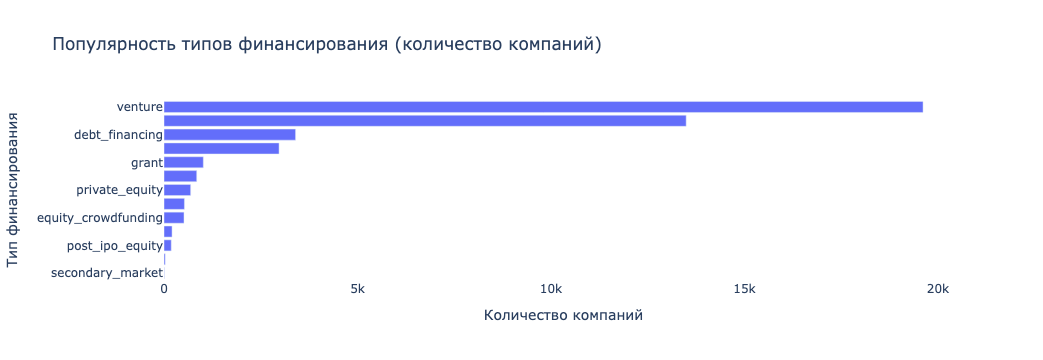

In [67]:
# Число компаний, у которых тип финансирования присутствует –– сумма > 0
funding_counts = (df_clean[funding_cols] > 0).sum().sort_values(ascending=False)

funding_counts_df = funding_counts.reset_index()
funding_counts_df.columns = ['funding_type', 'company_count']

fig_counts = px.bar(
    funding_counts_df,
    x='company_count',
    y='funding_type',
    orientation='h',
    title='Популярность типов финансирования (количество компаний)',
    labels={'company_count': 'Количество компаний', 'funding_type': 'Тип финансирования'}
)

fig_counts.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig_counts.update_xaxes(showgrid=False)
fig_counts.update_yaxes(showgrid=False)

fig_counts.show()

<font color='#777778'>
    
Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.
   
</font>

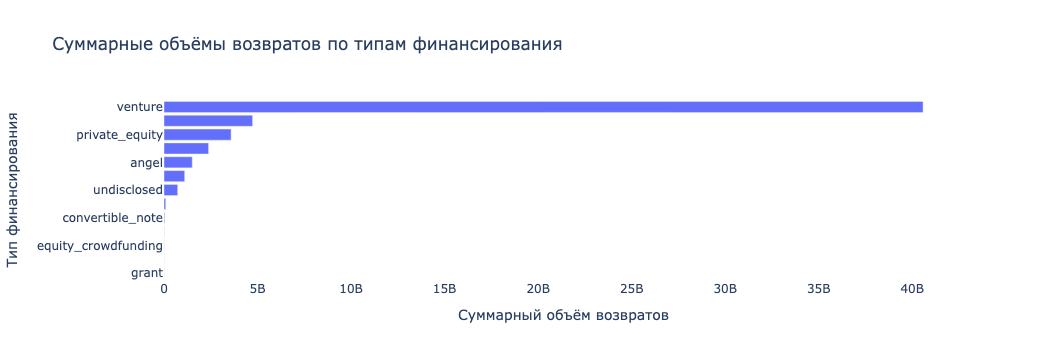

In [68]:
# Суммарные объёмы возвратов по каждому типу за весь период
returns_sums = df_returns[funding_cols].sum().sort_values(ascending=False)

returns_sums_df = returns_sums.reset_index()
returns_sums_df.columns = ['funding_type', 'total_returns']

fig_returns = px.bar(
    returns_sums_df,
    x='total_returns',
    y='funding_type',
    orientation='h',
    title='Суммарные объёмы возвратов по типам финансирования',
    labels={
        'total_returns': 'Суммарный объём возвратов',
        'funding_type': 'Тип финансирования'
    }
)

fig_returns.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig_returns.update_xaxes(showgrid=False)
fig_returns.update_yaxes(showgrid=False)

fig_returns.show()

<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">
    
- По суммарному объёму привлечённых средств лидирует `venture`, заметно отстают `seed`, `debt_financing` и `private_equity`, тогда как `secondary_market` и краудфандинг в целом дают очень небольшие объёмы.  
- По популярности чаще всего используются `venture` и `seed`; далее идут `debt_financing`, `angel`, `grant`, в то время как `post_ipo_debt`, `secondary_market` и `product_crowdfunding` встречаются редко.  
- Сравнение графиков показывает, что `seed` и `angel` — часто используемые, но относительно «мелкие» по объёму инструменты, а `private_equity` и `post_ipo_equity` применяются реже, но дают заметные суммарные объёмы.
- В данных по возвратам снова доминирует `venture`, тогда как краудфандинговые и вторичные инструменты остаются малозначимыми.

 **Рынок опирается на несколько крупных инструментов (`venture`, `debt_financing`, `private_equity`), в то время как посевные и ангельские раунды массовы, но меньшие по деньгам, а краудфандинг и вторичный рынок остаются нишевыми.**

</div>


[Назад к содержанию](#00-bullet) 

---
<a id="6-bullet"></a>
## Анализ динамики

<a id="61-bullet"></a>
### Динамика предоставления финансирования по годам

<font color='#777778'>
    
Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

   
</font>

In [69]:
# Средний объём одного раунда для каждой компании
df_active['avg_round_usd'] = df_active['funding_total_usd'] / df_active['funding_rounds']

# Оставим только компании с финансированием и раундами
df_rounds = df_active[
    (df_active['funding_total_usd'] > 0) & (df_active['funding_rounds'] > 0)
].copy()

df_rounds[['name', 'mid_year', 'funding_total_usd', 'funding_rounds', 'avg_round_usd']].head()

,name,mid_year,funding_total_usd,funding_rounds,avg_round_usd
1,University of New Brunswick,2014.0,2000000,1,2000000.0
2,DuPont,2009.0,9000000,1,9000000.0
3,University of Michigan,2013.0,7700000,3,2566666.666667
4,Case Western Reserve University,2014.0,540000,1,540000.0
6,Tulane University,2013.0,12000000,4,3000000.0


<font color='#777778'>
    


На основе получившейся таблицы построим графики, отражающие:
- динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;
- динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).
   
</font>

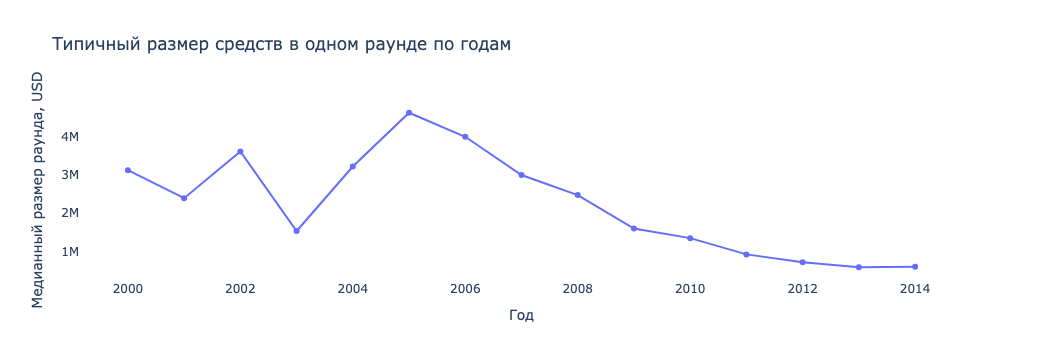

In [70]:
# Агрегируем по годам
year_stats = (
    df_rounds
    .groupby('mid_year')
    .agg(
        avg_round_year=('avg_round_usd', 'median'), # медиану внутри каждой группы по году запишем в новый столбец
        total_rounds_year=('funding_rounds', 'sum')
    )
    .reset_index()
    .rename(columns={'mid_year': 'year'})
    .sort_values('year')
)

# График "Динамика типичного размера средств за раунд"
fig_size = px.line(
    year_stats,
    x='year',
    y='avg_round_year',
    title='Типичный размер средств в одном раунде по годам',
    markers=True,
    labels={'year': 'Год', 'avg_round_year': 'Медианный размер раунда, USD'}
)
fig_size.update_xaxes(showgrid=False, zeroline=False)
fig_size.update_yaxes(showgrid=False, zeroline=False)

fig_size.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')

fig_size.show()

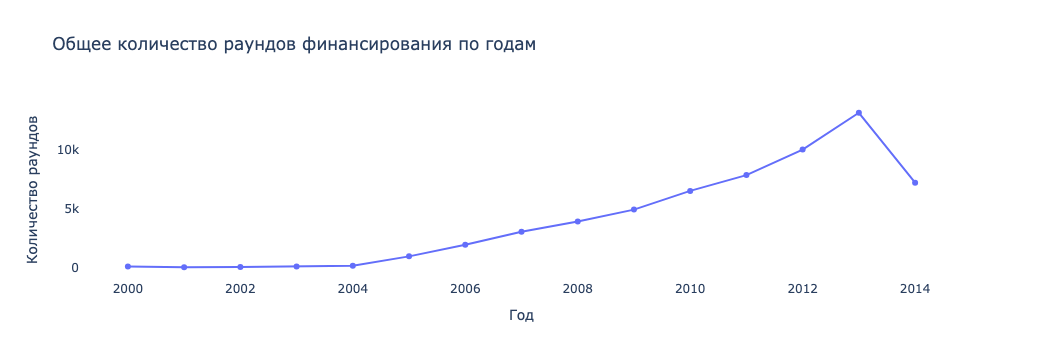

In [71]:
# График "Динамика общего количества раундов по годам"
fig_rounds = px.line(
    year_stats,
    x='year',
    y='total_rounds_year',
    title='Общее количество раундов финансирования по годам',
    markers=True,
    labels={'year': 'Год', 'total_rounds_year': 'Количество раундов'}
)
fig_rounds.update_xaxes(showgrid=False, zeroline=False)
fig_rounds.update_yaxes(showgrid=False, zeroline=False)

fig_rounds.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')

fig_rounds.show()

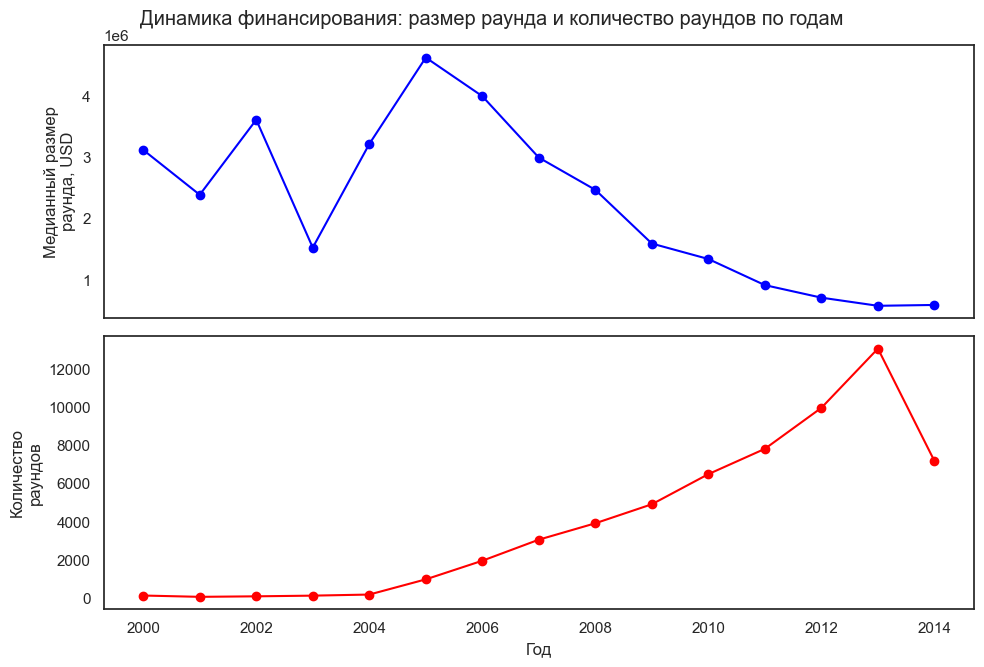

In [72]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 7)
)

x = year_stats['year'].to_numpy()
y_size = year_stats['avg_round_year'].to_numpy(dtype='float64')
y_rounds = year_stats['total_rounds_year'].to_numpy(dtype='float64')

# Типичный размер средств в одном раунде — ярко синий
ax1.plot(x, y_size, marker='o', color='blue')
ax1.set_ylabel('Медианный размер\nраунда, USD')

# Общее количество раундов — ярко красный
ax2.plot(x, y_rounds, marker='o', color='red')
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество\nраундов')

fig.suptitle('Динамика финансирования: размер раунда и количество раундов по годам', y=0.95)
plt.tight_layout()
plt.show()

<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">

- Максимальный типичный размер средств в одном раунде наблюдается в 2005 году: медианный размер раунда составляет примерно 4,63 млн USD.

- В 2014 году медианный размер раунда остаётся на уровне порядка 0,6 млн USD, близком к значениям 2012–2013 годов, но число раундов снижается с 13 104 в 2013 году до 7 205, что говорит о падении активности.

 **Максимальный «типичный» размер раунда пришёлся на 2005 год, а 2014 год выделяется снижением активности.**
    
</div>


[Назад к содержанию](#00-bullet) 

<a id="62-bullet"></a>
### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

<font color='#777778'>
    

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка.

   
</font>

In [73]:
# Сводная таблица: суммарный funding_total_usd по годам и сегментам рынка
pivot_funding = (
    df_clean
    .groupby(['mid_year', 'market'])['funding_total_usd']
    .sum()
    .reset_index()
    .rename(columns={
        'mid_year': 'year',
        'funding_total_usd': 'total_funding_usd'
    })
)

display(pivot_funding.head())

,year,market,total_funding_usd
0,1921.0,unknown_market,1000
1,1960.0,Biotechnology,75000
2,1960.0,Software,861030
3,1979.0,Enterprise Software,1000000
4,1982.0,unknown_market,1044000


<font color='#777778'>
    


Отберём из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.


   
</font>

In [74]:
# Оставляем только 2013 и 2014 годы
pivot_13_14 = pivot_funding[pivot_funding['year'].isin([2013.0, 2014.0])]

# Разворот в формат: строки – market, столбцы – годы
growth_13_14 = pivot_13_14.pivot(
    index='market',
    columns='year',
    values='total_funding_usd'
)

# Сегменты, где в 2014 суммарное финансирование > 2013
growing_segments = growth_13_14[
    (growth_13_14[2014.0] > growth_13_14[2013.0])
].index

print('Все сегменты с ростом в 2014 vs 2013')
print(list(growing_segments))

Все сегменты с ростом в 2014 vs 2013
['Apps', 'Design', 'Internet', 'Medical', 'Messaging', 'Real Estate', 'SaaS', 'Sports', 'Startups', 'Technology', 'Video', 'mid', 'niche', 'unknown_market']


<font color='#777778'>
    


На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Из рассмотрения сознательно исключаем средние `mid`, нишевые `niche`, а также технический сегмент `unknown_market`, так как он объединяет неоднородные компании с неуказанным рынком и может искажать восприятие динамики реальных рыночных направлений.

   
</font>

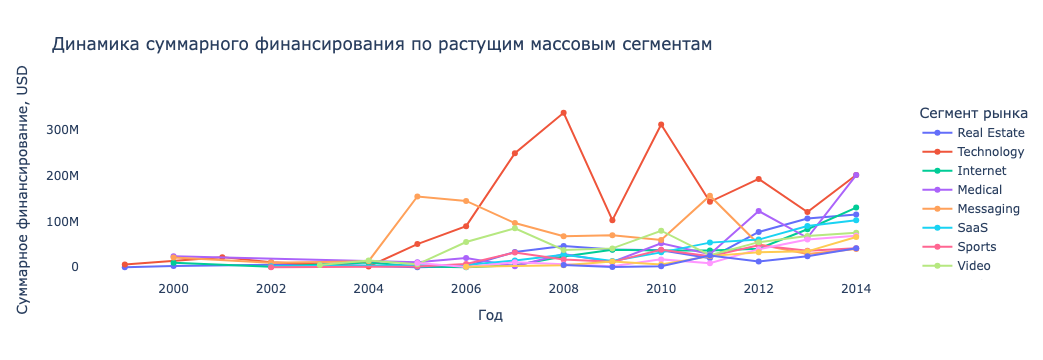

In [75]:
# Оставляем только отобранные сегменты
segments_data = pivot_funding[pivot_funding['market'].isin(growing_segments)].copy()

# Исключаем укрупнённые/служебные категории
segments_data = segments_data[~segments_data['market'].isin(['mid', 'niche', 'unknown_market'])]

# Строим график динамики суммарного финансирования по годам
fig = px.line(
    segments_data,
    x='year',
    y='total_funding_usd',
    color='market',
    markers=True,
    title='Динамика суммарного финансирования по растущим массовым сегментам',
    labels={
        'year': 'Год',
        'total_funding_usd': 'Суммарное финансирование, USD',
        'market': 'Сегмент рынка'
    }
)

fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">

- Наиболее быстрый и уверенный рост суммарного финансирования показывают массовые технологические сегменты, в первую очередь **Medical**, а также **Apps, Big Data, Design** и **Internet**, где к 2014 году объёмы инвестиций выходят на пиковые значения.
- Сегменты SaaS, Startups и Technology растут более плавно, но достаточно стабильно.
- Тогда как Real Estate увеличивает финансирование заметно медленнее.
    
 **Лидером по скорости и устойчивости роста суммарного финансирования среди массовых сегментов является Medical.**
</div>


[Назад к содержанию](#00-bullet) 

<a id="63-bullet"></a>
### Годовая динамика доли возвращённых средств по типам финансирования

<font color='#777778'>
    
Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств. При этом слишком большие аномальные значения заменим на пропуски.
   
</font>

In [76]:
# Привлечённые средства по годам
funding_by_year = (
    df_clean
    .groupby('mid_year')[funding_cols]
    .sum()
    .rename_axis('year')
)

# Нормированные возвраты
eps = 1e-60 # Защита от деления на 0
normalized_returns = df_returns / (funding_by_year + eps)

display(normalized_returns.head())

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
1921.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
# Считаем статистические характеристики
Q1 = normalized_returns.quantile(0.25)
Q3 = normalized_returns.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

bounds = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'lower_bound': lower_bound,
    'upper_bound': upper_bound
})

display(bounds)

,Q1,Q3,IQR,lower_bound,upper_bound
seed,0.279470,6.522010e-01,3.727309e-01,-2.796263e-01,1.211297e+00
venture,0.164162,5.149285e-01,3.507669e-01,-3.619888e-01,1.041079e+00
equity_crowdfunding,0.029199,NaN,NaN,NaN,NaN
undisclosed,0.254071,5.143630e-01,2.602920e-01,-1.363669e-01,9.048010e-01
convertible_note,0.048419,NaN,NaN,NaN,NaN
debt_financing,0.364936,5.931673e-01,2.282316e-01,2.258832e-02,9.355147e-01
angel,0.488971,7.946712e-01,3.056997e-01,3.042197e-02,1.253221e+00
grant,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
private_equity,0.169258,6.139419e-01,4.446834e-01,-4.977666e-01,1.280967e+00
post_ipo_equity,0.511778,2.185556e+00,1.673777e+00,-1.998888e+00,4.696222e+00


In [78]:
# Маска выбросов по IQR
outliers_iqr = (normalized_returns < lower_bound) | (normalized_returns > upper_bound)

print('Число выбросов по IQR для каждого типа финансирования:')
print(outliers_iqr.sum())

Число выбросов по IQR для каждого типа финансирования:
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             1
convertible_note        0
debt_financing          1
angel                   0
grant                   0
private_equity          1
post_ipo_equity         3
post_ipo_debt           3
secondary_market        0
product_crowdfunding    0
dtype: int64


In [79]:
normalized_returns_clean = normalized_returns.mask(outliers_iqr)

print('Нормированные возвраты без выбросов:')
display(normalized_returns_clean.head())

print('Описательная статистика без выбросов:')
display(normalized_returns_clean.describe())

Нормированные возвраты без выбросов:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
1921.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Описательная статистика без выбросов:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
count,15.000000,15.000000,9.000000,14.000000,14.000000,14.000000,15.000000,15.0,14.000000,12.000000,12.000000,1.500000e+01,7.000000
mean,0.525629,0.340136,inf,0.381487,inf,0.465193,0.674858,0.0,0.414309,0.854719,0.011492,2.340000e+65,0.025001
std,0.292455,0.213813,NaN,0.171005,NaN,0.165314,0.285019,0.0,0.274033,0.670483,0.039808,2.721817e+65,0.029327
min,0.145693,0.066357,0.006803,0.157616,0.006667,0.223388,0.246489,0.0,0.000000,0.246995,0.000000,6.217617e-03,0.000000
25%,0.279470,0.164162,0.029199,0.250068,0.048419,0.361156,0.488971,0.0,0.153221,0.460169,0.000000,2.049352e-01,0.006614
50%,0.505276,0.280629,0.087819,0.352912,0.066689,0.422859,0.605720,0.0,0.504004,0.632009,0.000000,8.000000e+64,0.012881
75%,0.652201,0.514928,NaN,0.490155,NaN,0.541634,0.794671,0.0,0.604374,0.898513,0.000000,4.650000e+65,0.040163
max,1.079592,0.733374,inf,0.759438,inf,0.789726,1.180000,0.0,0.768783,2.341111,0.137898,8.100000e+65,0.068571


<font color='#777778'>
    
Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.
   
</font>

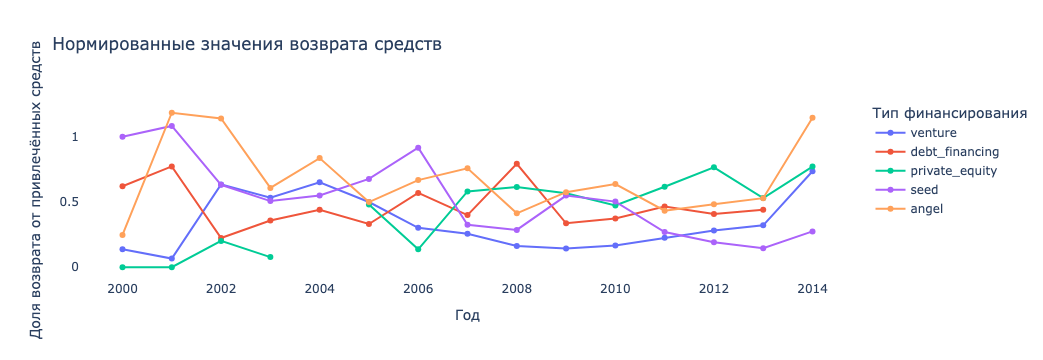

In [80]:
cols_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Берём только нужные столбцы и год
plot_data = (
    normalized_returns_clean[cols_to_plot]
    .dropna(how='all') # убираем годы, где все пять типов пропущены
    .reset_index()
    .rename(columns={'year': 'year'})
)

fig = px.line(
    plot_data,
    x='year',
    y=cols_to_plot,
    markers=True,
    title='Нормированные значения возврата средств',
    labels={
        'year': 'Год',
        'value': 'Доля возврата от привлечённых средств',
        'variable': 'Тип финансирования'
    }
)

fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

<div style="border: solid #AEBCC4 2px; padding: 40px; color: #777778;">

- Видно, что по большинству типов финансирования и по возвратам осмысленные данные появляются, начиная примерно с 2000 года.
- Наиболее устойчивый рост нормированной доли возврата средств наблюдается в сегментах `debt_financing` и `venture`:
    - для `debt_financing` показатель большую часть периода держится в районе 0.4–0.9 и достигает максимума около 1.24 в 2014 году;
    - для `venture` — в коридоре примерно 0.17–0.35 с резким ростом до 0.79 в 2014 году.
- Чуть менее ровный, но в целом достаточно стабильный рост демонстрирует `angel` (примерно 0.4–0.8 с выходом к 1.15 в 2014 году), тогда как `seed` и `private_equity` колеблются сильнее и не формируют столь выраженного устойчивого восходящего тренда.

  **Среди основных инструментов наиболее устойчивый рост нормированной доли возврата средств показывают debt_financing и venture, тогда как seed, angel и особенно private_equity ведут себя заметно более волатильно.**

</div>


[Назад к содержанию](#00-bullet) 

---
<a id="7-bullet"></a>
## Итоговый вывод и рекомендации

<a id="71-bullet"></a>
### Общий обзор проделанной работы

<div style="background-color: #AEBCC4; padding: 10px; border-radius: 4px;">
    
- В проекте были загружены и подробно исследованы два датасета: `cb_investments` с данными о компаниях и раундах финансирования и `cb_returns` с годовыми суммами возвратов по типам инструментов.
- Проведена предобработка: очищены и приведены к числовым/датовым типам ключевые признаки (`funding_total_usd`, даты), обработаны пропуски, удалены полные дубликаты и строки без финансирования, оптимизированы типы и выделен рабочий поднабор из более чем 40 тысяч компаний.
- Затем выполнен инжиниринг признаков (длительность и группы по сроку финансирования, укрупнённые рыночные сегменты `mass` / `mid` / `niche`), анализ выбросов и фильтрация по активным годам, построены агрегаты и графики по объёмам, популярности и возвратам для разных типов финансирования и рынков.
- На финальном этапе оценена динамика: типичный размер раунда и число раундов по годам, рост суммарного финансирования по массовым сегментам и устойчивость нормированной доли возврата по основным типам инструментов (`venture`, `debt_financing`, `private_equity`, `seed`, `angel`).
    
</div>

[Назад к содержанию](#00-bullet) 

<a id="72-bullet"></a>
### Ключевые выводы

<div style="background-color: #AEBCC4; padding: 10px; border-radius: 4px;">
    
- Рынок сильно асимметричен: около 59 % компаний получают только один раунд, но на них приходится примерно 31 % капитала, тогда как около 30 % «долгоживущих» компаний (более года между первым и последним раундом) аккумулируют почти 62 % всех инвестиций. 
- Структура по отраслям имеет вид «несколько крупных направлений + длинный хвост»: несколько массовых рынков (Software, Biotechnology, Mobile, E‑Commerce, Medical и др.) дают львиную долю компаний и объёмов, а сотни нишевых сегментов малы по отдельности, но многочисленны. 
- По объёмам и возвратам ядро рынка составляют `venture`, `debt_financing` и частично `private_equity`: именно через них проходит основная масса денег и возвратов, тогда как `seed` и `angel` используются часто, но остаются относительно «мелкими» по сумме, а краудфандинг и `secondary_market` остаются нишевыми как по объёму, так и по возвратам. 
- По динамике 2000–2013 годов рынок растёт и по числу раундов, и по совокупному финансированию; 2014 год выглядит неполным (падение числа раундов при сопоставимом размере раунда). Среди массовых сегментов к 2014 году лучше всего растут Medical, Apps, Big Data, Design, Internet, а по нормированной доле возврата наиболее устойчивую траекторию показывают `debt_financing` и `venture`.
- В совокупности выводы согласуются: долгие многораундовые истории в крупных технологических и медицинских сегментах тянут на себя основную массу капитала и возвратов, а ранние и нишевые истории многочисленны, но менее значимы по деньгам; единственная зона сомнений — интерпретация 2014 года, который по активности явно неполон.
    
</div>

[Назад к содержанию](#00-bullet) 

<a id="73-bullet"></a>
### Рекомендации для заказчика

<div style="background-color: #AEBCC4; padding: 10px; border-radius: 4px;">
   

**Отрасли для фокуса.**  
- Рекомендуется сфокусироваться на массовых тех‑сегментах с уверенным ростом к 2014 году: прежде всего Medical (health‑tech), а также Apps, Big Data, Design и Internet. 

**Типы финансирования.**  
- Базовый инструмент — `venture`: он лидирует по объёму привлечённых средств и возвратов и является ключевым для растущих тех‑ и мед‑стартапов.
- В дополнение стоит использовать `debt_financing` для более зрелых компаний: нормированная доля возврата по нему стабильна и высока. 
- `Seed` и `angel` — точечно для раннего входа в перспективные ниши, основная доля капитала — в связке `venture` + `debt_financing`.

**Ограничения и дальнейшие шаги.**  
- Данные за 2014 год по активности выглядят неполными, динамику этого года нужно трактовать осторожно.
- Для уточнения стратегии полезно: проверить данные за 2014 год и детальнее исследовать внутри выбранных сегментов стадии и географию сделок.
 
    
</div>

[Назад к содержанию](#00-bullet) 